In [1]:
import sys
sys.path.append("/var/www/python/Prod/nighthawk/")
import pandas as pd
import numpy as np

from nighthawk.data.pipeline.common_functions import wind, load, genoutage
from nighthawk.util import dataframe_functions, bigquery_functions, connections, sql_functions
from nighthawk.models.portfolioOpt import ve_portfolio_constructor
from nighthawk.data.network import node
import gc
pd.set_option('display.max_columns', None)



In [2]:
# start_dt = '2022-01-11' # no Darwin data from 2022-01-01 to 2022-01-10 
start_dt = '2020-01-01'
end_dt = '2026-05-19'
opexchange = 'SPP'
strategy_list_dict = {'SPP': ['Darwin', 'Fourier']}
file_loc = '/mnt/disks/filedisk2a/Jessica/tmp/'

ve_port = ve_portfolio_constructor.VEPortfolioConstructor(opexchange)


## Generate Portfolio

In [3]:
# darwin backtest > curie_backtest > pre cuts table
# all strategies are adjusted to the current scale

def get_portfolio(opexchange, start_dt, end_dt, strategy_list_dict, target_scale_factor): 


    # if target_scale_factor['Curie'] is None:
    #     target_curie_scale = sql_functions.download_df_from_sql_db(f"""SELECT scale FROM Curie_SPP.SPPCurieScaleFactor order by dt desc limit 1""")['scale'].values[0]
    # else:
    #     target_curie_scale = target_scale_factor['Curie']
        
    if target_scale_factor['Fourier'] is None:
        target_fourier_scale = sql_functions.download_df_from_sql_db(f"""SELECT scale_factor FROM Fourier_SPP.scaleFactor order by dt desc limit 1""")['scale_factor'].values[0]
    else:
        target_fourier_scale = target_scale_factor['Fourier']

    if target_scale_factor['Darwin'] is None:
        target_darwin_scale = sql_functions.download_df_from_sql_db(f"""SELECT scale_factor FROM Darwin_SPP.scaleFactor order by dt desc limit 1""")['scale_factor'].values[0]
    else:
        target_darwin_scale = target_scale_factor['Darwin']
        
    if target_scale_factor['Eigen'] is None:
        target_darwin_v2_scale = sql_functions.download_df_from_sql_db(f"""SELECT scale_factor FROM Eigen_SPP.scaleFactor order by dt desc limit 1""")['scale_factor'].values[0]
    else:
        target_darwin_v2_scale = target_scale_factor['Eigen']
    print('target_fourier_scale: ', target_fourier_scale)
    print('target_darwin_scale: ', target_darwin_scale)
    print('target_darwin_v2_scale: ', target_darwin_v2_scale)


    def _wind_scale_factor(row):
        """
        decide portfolio scale factor given daily wind percentile

        :author: jessica_xia
        :date: 2022-10-07
        :param row: 120DPec_daily_wind variable ranging from 0 to 1
        :return: int, wind scale factor
        """

        if row <= 0.05:
            return 0.4
        elif row <= 0.3:
            return 0.8
        elif row <= 0.9:
            return 1
        else:
            # 05/10/2022: change from 1.05 to 1.25
            return 1.25

    def scale_by_wind(start_dt, end_dt, opexchange):


        wind_start_dt = (pd.to_datetime(start_dt) - pd.to_timedelta('125D')).strftime('%Y-%m-%d')
        wind_obj = wind.Wind(opexchange)
        daily_wind_df = wind_obj.get_total_wind(wind_start_dt, end_dt, var_spec=['f'], impute=True)

        # daily wind
        col = 'daily_total_wind_forecast_f'
        n_day = 120
        perc_col_name = str(n_day) + 'DPerc_' + col
        scale_col_name = 'scale_by_' + perc_col_name
        daily_wind_df = daily_wind_df.groupby(['dt'])['spp_wind_total_forecast_f'].agg(['mean']).reset_index()
        daily_wind_df.columns = ['dt', col]
        daily_wind_df[perc_col_name] = daily_wind_df[col].rolling(n_day, min_periods=1).apply(
            lambda x: pd.Series(x).rank(pct=True).iloc[-1])

        # create daily scale factor
        daily_wind_df[scale_col_name] = daily_wind_df[perc_col_name].apply(_wind_scale_factor)
        daily_wind_df = daily_wind_df[['dt', scale_col_name]]
        daily_wind_df = daily_wind_df[(daily_wind_df['dt'] >= start_dt)&(daily_wind_df['dt'] <= end_dt)]

        return daily_wind_df

    darwin_wind_scale = scale_by_wind(start_dt, end_dt, opexchange)
    display(darwin_wind_scale.head())


    # # Curie bq
    # curieBacktest = bigquery_functions.download_df_from_bq(f"""
    # SELECT distinct dt, hr, 'Curie' as strategy, incdec, segment, node_num, bid_mw, bid_price
    # FROM `movetocloud-999.SPP_Curie_backtest.segmentBucketNew`
    # where holdout = 0 and version=0 and dt>='{start_dt}' and dt<='{end_dt}' and bid_mw != 0
    # UNION ALL
    # SELECT distinct dt, hr, 'Curie' as strategy, incdec, segment, node_num, bid_mw, bid_price
    # FROM `movetocloud-999.Curie_Production.bidsTableSPP`
    # where dt>='{start_dt}' and dt<='{end_dt}'  and run_number=2 and cut = 1 and bid_mw != 0
    #  """)
    # curieBacktest.dt = curieBacktest.dt.astype(str)
    # curieBacktest.hr = curieBacktest.hr.astype(int)
    # curieBacktest.node_num = curieBacktest.node_num.astype(int)
    # # adjust precut curie to target_scale_factor
    # curieBacktest['bid_mw'] = curieBacktest['bid_mw']*target_curie_scale

    # # darwin bq
    # darwinV0Backtest = bigquery_functions.download_df_from_bq(f"""
    # SELECT cast(dt as date) as dt, hr, 'DarwinV0' as strategy, incdec, segment, node_num, bid_mw, bid_price
    # FROM `movetocloud-999.Darwin.SPP_bids_table`
    # WHERE nodeSelection = 'nodeLookback45_lmpLookback7_curieCorrCutF_dfMeanoff_pcNode2_cutoff90' and option = 'option24'
    # and dt>='{start_dt}' and dt<='{end_dt}' and bid_mw != 0
    # UNION ALL
    # SELECT cast(dt as date) as dt, hr, 'DarwinV0' as strategy, incdec, segment, node_num, bid_mw, bid_price
    # FROM `movetocloud-999.Darwin_Production.SPP_bids_table`
    # WHERE dt>='{start_dt}' and dt<='{end_dt}'  and run_number = 2 and cut = 1 and bid_mw != 0
    #  """)
    # darwinV0Backtest['dt'] = darwinV0Backtest['dt'].astype(str)
    # darwinV0Backtest['hr'] = darwinV0Backtest['hr'].astype(int)
    # darwinV0Backtest['node_num'] = darwinV0Backtest['node_num'].astype(int)
    # # adjust precut darwin to target_scale_factor
    # darwinV0Backtest['bid_mw'] = darwinV0Backtest['bid_mw']*target_darwin_scale
    # darwinV0Backtest = darwinV0Backtest.merge(darwin_wind_scale)
    # darwinV0Backtest['bid_mw'] = darwinV0Backtest['bid_mw']*darwinV0Backtest['scale_by_120DPerc_daily_total_wind_forecast_f']
    # darwinV0Backtest = darwinV0Backtest.drop(columns=['scale_by_120DPerc_daily_total_wind_forecast_f'])
    
    darwinV1Backtest = bigquery_functions.download_df_from_bq(f"""
    SELECT cast(dt as date) as dt, hr, 'Darwin' as strategy, 'backtest' as source, incdec, segment, node_num, bid_mw, bid_price
    FROM `movetocloud-999.spp.darwin_v2_bids_table`
    WHERE model = 'darwin_aggressive' and portfolio = 'reduced_darwin'
    and dt>='{start_dt}' and dt<='{end_dt}' and bid_mw != 0
        UNION ALL
    SELECT cast(dt as date) as dt, hr, 'Darwin' as strategy, 'production' as source, incdec, segment, node_num, bid_mw, bid_price
    FROM `movetocloud-999.Darwin_Production.SPP_bids_table`
    WHERE dt>='{start_dt}' and dt<='{end_dt}'  and run_number = 2 and cut = 1 and bid_mw != 0
     """)
    darwinV1Backtest['dt'] = darwinV1Backtest['dt'].astype(str)
    darwinV1Backtest['hr'] = darwinV1Backtest['hr'].astype(int)
    darwinV1Backtest['node_num'] = darwinV1Backtest['node_num'].astype(int)
    # adjust precut darwin to target_scale_factor
    darwinV1Backtest['bid_mw'] = darwinV1Backtest['bid_mw']*target_darwin_scale
    darwinV1Backtest = darwinV1Backtest.merge(darwin_wind_scale)
    darwinV1Backtest['bid_mw'] = darwinV1Backtest['bid_mw']*darwinV1Backtest['scale_by_120DPerc_daily_total_wind_forecast_f']
    darwinV1Backtest = darwinV1Backtest.drop(columns=['scale_by_120DPerc_daily_total_wind_forecast_f'])

    darwinV2Backtest = bigquery_functions.download_df_from_bq(f"""
    SELECT cast(dt as date) as dt, hr, 'Eigen' as strategy, 'backtest' as source, incdec, segment, node_num, bid_mw, bid_price
    FROM `movetocloud-999.spp.darwin_v2_bids_table`
    WHERE model = 'reduced_aggressive_3' and portfolio = 'reduced_darwin'
    and dt>='{start_dt}' and dt<='{end_dt}' and bid_mw != 0
    UNION ALL
    SELECT cast(dt as date) as dt, hr, 'Eigen' as strategy, 'production' as source, incdec, segment, node_num, bid_mw, bid_price
    FROM `movetocloud-999.Eigen_Production.SPP_bids_table`
    WHERE dt>='{start_dt}' and dt<='{end_dt}'  and run_number = 2 and cut = 1 and bid_mw != 0
     """)
    darwinV2Backtest['dt'] = darwinV2Backtest['dt'].astype(str)
    darwinV2Backtest['hr'] = darwinV2Backtest['hr'].astype(int)
    darwinV2Backtest['node_num'] = darwinV2Backtest['node_num'].astype(int)
    # adjust precut darwin to target_scale_factor
    darwinV2Backtest['bid_mw'] = darwinV2Backtest['bid_mw']*target_darwin_v2_scale
#     darwinBacktest = darwinBacktest.merge(darwin_wind_scale)
#     darwinBacktest['bid_mw'] = darwinBacktest['bid_mw']*darwinBacktest['scale_by_120DPerc_daily_total_wind_forecast_f']
#     darwinBacktest = darwinBacktest.drop(columns=['scale_by_120DPerc_daily_total_wind_forecast_f'])
    
    # fourier bq
    fourierBacktest = bigquery_functions.download_df_from_bq(f"""
    SELECT cast(dt as date) as dt, hr, 'Fourier' as strategy, 'backtest' as source, incdec, segment, node_num, bid_mw, bid_price
    FROM `movetocloud-999.Fourier_Backtest.SPP_bids_table`
    WHERE nodeSelection = 'Darwin' and model = 'dnn_32h1_8h2' and portfolio = 'Terrence_v2'
    and dt>='{start_dt}' and dt<='{end_dt}' and bid_mw != 0
    UNION ALL
    SELECT cast(dt as date) as dt, hr, 'Fourier' as strategy, 'production' as source, incdec, segment, node_num, bid_mw, bid_price
    FROM `movetocloud-999.Fourier_Production.SPP_bids_table`
    WHERE dt>='{start_dt}' and dt<='{end_dt}'  and run_number = 2 and cut = 1 and bid_mw != 0
     """)
    fourierBacktest['dt'] = fourierBacktest['dt'].astype(str)
    fourierBacktest['hr'] = fourierBacktest['hr'].astype(int)
    fourierBacktest['node_num'] = fourierBacktest['node_num'].astype(int)
    # adjust precut darwin to target_scale_factor
    fourierBacktest['bid_mw'] = fourierBacktest['bid_mw']*target_fourier_scale


#     # precut table
#     precut_tbl = 'odessa_Bid.SPPFinalBidsBeforeAnyCut'
#     strategy_str = "'" + "' ,'".join(strategy_list_dict[opexchange]) + "'"
#     precuts_segs = sql_functions.download_df_from_sql_db(f""" 
#     SELECT 
#        distinct dt, hr, strategy ,incdec, segment, node_num, bid_mw, bid_price
#     FROM {precut_tbl} as a
#     where a.dt>='{start_dt}' and a.dt<='{end_dt}' 
#     and strategy in ({strategy_str})
#     """)
#     precuts_segs['dt'] = precuts_segs['dt'].astype(str)
#     precuts_segs['hr'] = precuts_segs['hr'].astype(int)
# #     # adjust precut curie to target_scale_factor
# #     curie_scale = sql_functions.download_df_from_sql_db(f"""SELECT distinct *, 'Curie' as strategy FROM Curie_SPP.SPPCurieScaleFactor""")
# #     curie_scale['dt'] = curie_scale['dt'].astype(str)
# #     curie_scale = precuts_segs[['dt']].drop_duplicates().merge(curie_scale)
# #     curie_scale['scale'] = target_curie_scale/curie_scale['scale'] 
#     # adjust precut darwin to target_scale_factor
#     darwin_scale = sql_functions.download_df_from_sql_db(f"""SELECT distinct * FROM Darwin_SPP.scaleFactor""")
#     darwin_scale['dt'] = darwin_scale['dt'].astype(str)
#     if darwin_scale['dt'].max() < precuts_segs['dt'].min(): 
#         darwin_scale_factor_value = darwin_scale.loc[darwin_scale['dt'] == darwin_scale['dt'].max(), 'scale_factor'].values[0]
#         darwin_scale = precuts_segs[['dt']].drop_duplicates()
#         darwin_scale['scale'] = darwin_scale_factor_value
#     else:
#         darwin_scale = precuts_segs[['dt']].drop_duplicates().merge(darwin_scale.rename(columns={'scale_factor': 'scale'}), how='left')
#         darwin_scale['scale'] = darwin_scale['scale'].ffill()
#     darwin_scale['strategy'] = 'Darwin'
#     darwin_scale = darwin_scale[~darwin_scale['scale'].isna()]
#     darwin_scale['scale'] = target_darwin_scale/darwin_scale['scale'] 
#     darwin_scale = darwin_scale.merge(darwin_wind_scale)
#     darwin_wind_scale_prod_start_dt = '2022-05-12'
#     darwin_scale['scale_by_120DPerc_daily_total_wind_forecast_f'] = np.where(darwin_scale['dt'] >= darwin_wind_scale_prod_start_dt, 1, darwin_scale['scale_by_120DPerc_daily_total_wind_forecast_f'])
#     darwin_scale['scale'] = darwin_scale['scale']*darwin_scale['scale_by_120DPerc_daily_total_wind_forecast_f']
#     darwin_scale = darwin_scale.drop(columns=['scale_by_120DPerc_daily_total_wind_forecast_f'])

#     # adjust precut fourier to target_scale_factor
#     fourier_scale = sql_functions.download_df_from_sql_db(f"""SELECT distinct * FROM Fourier_SPP.scaleFactor""")
#     fourier_scale['dt'] = fourier_scale['dt'].astype(str)
#     if fourier_scale['dt'].max() < precuts_segs['dt'].min(): 
#         fourier_scale_factor_value = fourier_scale.loc[fourier_scale['dt'] == fourier_scale['dt'].max(), 'scale_factor'].values[0]
#         fourier_scale = precuts_segs[['dt']].drop_duplicates()
#         fourier_scale['scale'] = fourier_scale_factor_value
#     else:
#         fourier_scale = precuts_segs[['dt']].drop_duplicates().merge(fourier_scale.rename(columns={'scale_factor': 'scale'}), how='left')
#         fourier_scale['scale'] = fourier_scale['scale'].ffill()
#     fourier_scale['strategy'] = 'Fourier'
#     fourier_scale = fourier_scale[~fourier_scale['scale'].isna()]
#     fourier_scale['scale'] = target_fourier_scale/fourier_scale['scale'] 
    
# #     precuts_segs = precuts_segs.merge(pd.concat([curie_scale, darwin_scale]))
#     precuts_segs = precuts_segs.merge(pd.concat([fourier_scale, darwin_scale]))
#     precuts_segs['bid_mw'] = precuts_segs['bid_mw']*precuts_segs['scale']
#     precuts_segs = precuts_segs.drop(columns=['scale'])

    # combine all
#     portfolio_precuts = pd.concat([darwinBacktest.assign(source='bq'), curieBacktest.assign(source='bq'), precuts_segs.assign(source='sql')])
#     portfolio_precuts = pd.concat([darwinBacktest.assign(source='bq'), fourierBacktest.assign(source='bq'), darwinV2Backtest.assign(source='bq'), precuts_segs.assign(source='sql')])
#     portfolio_precuts = pd.concat([darwinBacktest.assign(source='bq'), fourierBacktest.assign(source='bq'), darwinV2Backtest.assign(source='bq')])
    portfolio_precuts = pd.concat([darwinV1Backtest, fourierBacktest, darwinV2Backtest])

    portfolio_precuts = portfolio_precuts[['dt', 'strategy', 'source']].drop_duplicates(['dt', 'strategy'], keep='first').merge(portfolio_precuts)
    cols_tmp = ['dt', 'hr', 'strategy', 'node_num', 'incdec', 'segment']
    portfolio_precuts = portfolio_precuts.drop(columns = ['source']).sort_values(by=cols_tmp).reset_index(drop=True)
    portfolio_precuts['bid_mw'] = portfolio_precuts['bid_mw'].astype(float)
    
    return portfolio_precuts

In [4]:

def _wind_scale_factor(row):
    """
    decide portfolio scale factor given daily wind percentile

    :author: jessica_xia
    :date: 2022-10-07
    :param row: 120DPec_daily_wind variable ranging from 0 to 1
    :return: int, wind scale factor
    """

    if row <= 0.05:
        return 0.4
    elif row <= 0.3:
        return 0.8
    elif row <= 0.9:
        return 1
    else:
        # 05/10/2022: change from 1.05 to 1.25
        return 1.25

def scale_by_wind(start_dt, end_dt, opexchange):


    wind_start_dt = (pd.to_datetime(start_dt) - pd.to_timedelta('125D')).strftime('%Y-%m-%d')
    wind_obj = wind.Wind(opexchange)
    daily_wind_df = wind_obj.get_total_wind(wind_start_dt, end_dt, var_spec=['f'], impute=True)

    # daily wind
    col = 'daily_total_wind_forecast_f'
    n_day = 120
    perc_col_name = str(n_day) + 'DPerc_' + col
    scale_col_name = 'scale_by_' + perc_col_name
    daily_wind_df = daily_wind_df.groupby(['dt'])['spp_wind_total_forecast_f'].agg(['mean']).reset_index()
    daily_wind_df.columns = ['dt', col]
    daily_wind_df[perc_col_name] = daily_wind_df[col].rolling(n_day, min_periods=1).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1])

    # create daily scale factor
    daily_wind_df[scale_col_name] = daily_wind_df[perc_col_name].apply(_wind_scale_factor)
#     daily_wind_df = daily_wind_df[['dt', scale_col_name]]
    daily_wind_df = daily_wind_df[(daily_wind_df['dt'] >= start_dt)&(daily_wind_df['dt'] <= end_dt)]

    return daily_wind_df

# darwin_wind_scale = scale_by_wind('2019-01-01', '2021-12-31', opexchange)
# display(darwin_wind_scale.head())
# table_fullname = "Darwin_SPP" + ".scaleFactorWind"
# sql_functions.replace_into_sql_table(darwin_wind_scale, table_fullname)

In [ ]:
target_scale_factor = {'Darwin': 1.0, 'Fourier': 1.0, 'Eigen': 1.0}
portfolio_precuts = get_portfolio(opexchange, start_dt, end_dt, strategy_list_dict, target_scale_factor)
# portfolio_precuts.to_csv(file_loc + 'portfolio_df_Nov2025.csv', index=False)

In [ ]:
portfolio_precuts.groupby(['strategy']).agg({'dt': 'min', 'dt': 'max', 'dt': 'nunique'})


,dt
strategy,
Darwin,2234
Eigen,2073
Fourier,2250


<Axes: xlabel='dt'>

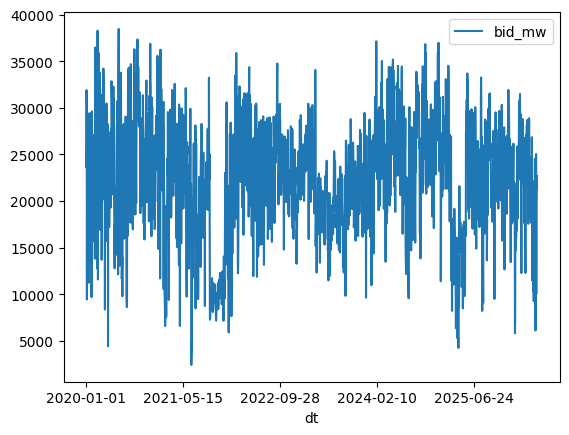

In [ ]:


temp = portfolio_precuts.groupby(['dt'])['bid_mw'].sum().reset_index()
temp.plot('dt', 'bid_mw')

<Axes: xlabel='dt'>

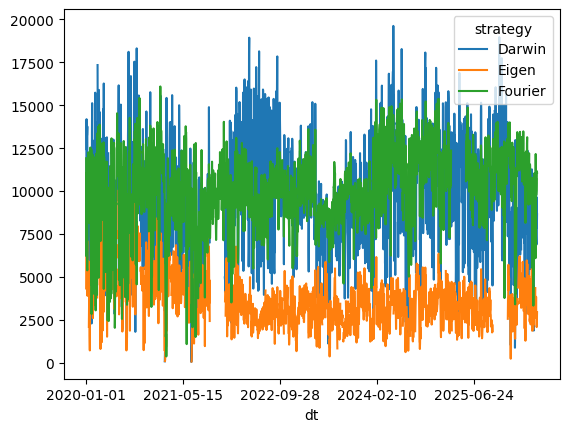

In [ ]:
pd.pivot_table(portfolio_precuts, index=['dt'], columns =['strategy'], values='bid_mw', aggfunc='sum').plot()

In [22]:
node_profile = \
    node.Node(node_nums=portfolio_precuts['node_num'].unique().tolist(), market=opexchange).get_node_profile()[
        ['node_num', 'capacity']]
node_profile['multiplier'] = node_profile['capacity'].map({'low': 0, 'medium': 0.3, 'high': 0.6, 'ext_high': 0.6})

# add highCap strategy
temp = portfolio_precuts[portfolio_precuts['strategy'] == 'Darwin'].merge(node_profile[['node_num', 'multiplier']], on='node_num')
temp['bid_mw'] = temp['bid_mw'] * temp['multiplier']
temp = temp[temp['bid_mw'] >= 0.1].drop(columns=['multiplier'])
temp['strategy'] = 'DarwinHighCap'
portfolio_precuts = pd.concat([portfolio_precuts, temp])

# add capacity column
portfolio_precuts = portfolio_precuts.merge(node_profile[['node_num', 'capacity']], on=['node_num'], how='left', suffixes=('_duplicatedwhenjoin', ''))
portfolio_precuts['capacity'] = portfolio_precuts['capacity'].fillna('low')

In [23]:
portfolio_precuts.to_csv(file_loc + 'portfolio_df_May2026.csv', index=False)

In [24]:
# # get op_rate and ref price
ref_df = portfolio_precuts[['dt', 'node_num']].drop_duplicates()
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['node_num'] = ref_df['node_num'].astype(int)
ref_df = dataframe_functions.cross_join(ref_df, pd.DataFrame({'hr': range(1, 25)}))
ve_port = ve_portfolio_constructor.VEPortfolioConstructor(opexchange)
ref_df = ve_port.get_oprate_lmp_price_and_ref_value(ref_df)
if opexchange == 'SPP': 
    node_obj = node.Node(ref_df['node_num'].unique().tolist(), opexchange)
    node_detail = node_obj.get_reserve_zones()
    ref_df = ref_df.merge(node_detail[['node_num', 'reserve_zone']].drop_duplicates())
    ref_df['reserve_zone'] = ref_df['reserve_zone'].astype(int)
ref_df.to_csv(file_loc + 'reference_df.csv', index=False)


In [25]:
ref_df.head()

,dt,node_num,hr,node_name,zone,state,rep_zone,rep_zone_opexchange,broad_zone,baa_zone,broad_zone_oprate_df,op_rate_inc_a,op_rate_dec_a,op_rate_inc_f,op_rate_dec_f,da_congestion,da_total,da_slack,rt_congestion,rt_total,rt_slack,bid_ref_price,offer_ref_price,reserve_zone
0,2020-01-01,6,1,AECC_FITZHUGH,CSWS,OK,CSWS,SPP,SOUTH,E,SOUTH,1.3121,0.9746,1.6623,0.3079,15.789700,26.810101,10.2941,196.018906,198.574905,2.3535,-26.33,-33.44,4
1,2020-01-01,6,2,AECC_FITZHUGH,CSWS,OK,CSWS,SPP,SOUTH,E,SOUTH,1.3121,0.9746,1.6623,0.3079,16.818501,27.024000,9.5179,107.458099,112.101097,4.3015,-26.33,-33.44,4
2,2020-01-01,6,3,AECC_FITZHUGH,CSWS,OK,CSWS,SPP,SOUTH,E,SOUTH,1.3121,0.9746,1.6623,0.3079,18.109501,28.000099,9.1948,89.892799,91.873100,1.8366,-26.33,-33.44,4
3,2020-01-01,6,4,AECC_FITZHUGH,CSWS,OK,CSWS,SPP,SOUTH,E,SOUTH,1.3121,0.9746,1.6623,0.3079,15.438000,26.031401,9.8470,69.146202,73.803802,4.3217,-26.33,-33.44,4
4,2020-01-01,6,5,AECC_FITZHUGH,CSWS,OK,CSWS,SPP,SOUTH,E,SOUTH,1.3121,0.9746,1.6623,0.3079,12.407900,25.325001,12.0225,78.637299,84.495796,5.4393,-26.33,-33.44,4


## Fetch Data

In [3]:
metric_cols = ['bid_mw', 'clear_mw', 'profit', 'profit_congestion', 'profit_slack',
       'profit_oprate', 'profit_pos',
       'profit_neg', 'investment']


def calculate_derived_profit_cols(df, da_total_col = 'da_total', min_mw = 0.1, bid_mw_col = 'bid_mw', bid_price_col = 'bid_price'):
    df = df[df['bid_mw'] > min_mw].copy()
    
    df['clear_mw'] = np.where(df['incdec'] == 'Decrement', df['bid_mw'] * (df['bid_price'] > df[da_total_col]),
                              df['bid_mw'] * (df['bid_price'] < df[da_total_col])).round(1)
    df['profit'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] *
                            (df['rt_total'] - df[da_total_col] -
                             df['op_rate_dec_a']),
                            df['clear_mw'] *
                            (df[da_total_col] - df['rt_total'] - df['op_rate_inc_a']))
    df['profit_congestion'] = np.where(df['incdec'] == 'Decrement',
                                       df['clear_mw'] *
                                       (df['rt_congestion'] -
                                        df['da_congestion']),
                                       df['clear_mw'] *
                                       (df['da_congestion'] - df['rt_congestion']))
    df['profit_slack'] = np.where(df['incdec'] == 'Decrement',
                                  df['clear_mw'] *
                                  (df['rt_slack'] - df['da_slack']),
                                  df['clear_mw'] *
                                  (df['da_slack'] - df['rt_slack']))
    df['profit_oprate'] = np.where(df['incdec'] == 'Decrement', -df['clear_mw'] * df['op_rate_dec_a'],
                                   -df['clear_mw'] * df['op_rate_inc_a'])

    if opexchange.upper() == 'SPP':  # collateral rule for SPP
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['bid_mw'] * df['bid_ref_price']),
                                       abs(df['bid_mw'] * df['offer_ref_price']))
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', abs(df['clear_mw'] * df['bid_ref_price']),
                                        abs(df['clear_mw'] * df['offer_ref_price']))
    else:
        df['bidCollateral'] = np.where(df['incdec'] == 'Decrement', df['bid_mw'] * df['bid_ref_price'],
                                       df['bid_mw'] * df['offer_ref_price'])
        df['holdCollateral'] = np.where(df['incdec'] == 'Decrement', df['clear_mw'] * df['bid_ref_price'],
                                        df['clear_mw'] * df['offer_ref_price'])

    df['profit_pos'] = np.maximum(df['profit'], 0)
    df['profit_neg'] = np.minimum(df['profit'], 0)
    df['investment'] = df['clear_mw'] * df[da_total_col]
    df['investment'] = np.where(df['incdec'] == 'Increment', df['investment'], -df['investment'])
    return df



def generateSummaryStatistics(inputDataFrame):
    numRows = inputDataFrame.shape[0]
    if numRows > 10:
        #         print("Calculating Summary")
        count = inputDataFrame[['dt', 'hr']].drop_duplicates().shape[0]
        totalDt = inputDataFrame['dt'].drop_duplicates().shape[0]
        totalBidMw = inputDataFrame['bid_mw'].sum()
        totalClearedMw = inputDataFrame['clear_mw'].sum()
        clearingPercentage = totalClearedMw*100/totalBidMw

        totalopRate = -1*inputDataFrame['profit_oprate'].sum()
        netProfit = inputDataFrame['profit'].sum()
        positiveHourlyProfit = inputDataFrame['profit_pos'].sum()
        negativeHourlyProfit = inputDataFrame['profit_neg'].sum()
        hourlyTradeRatio = -1*positiveHourlyProfit/negativeHourlyProfit
        profitPerBidMw = netProfit/totalBidMw
        profitPerClearedMw = netProfit/totalClearedMw
        congestionTotalProfit = inputDataFrame['profit_congestion'].sum()
        congestionPositiveProfit = inputDataFrame[inputDataFrame['profit_congestion'] > 0].profit_congestion.sum(
        )
        congestionNegativeProfit = inputDataFrame[inputDataFrame['profit_congestion'] < 0].profit_congestion.sum(
        )
        congestionHourlyTradeRatio = -1*congestionPositiveProfit/congestionNegativeProfit

        averageHourlyProfit = inputDataFrame['profit'].mean()
        # added this for SPP
        var1Percentile = np.percentile(inputDataFrame['profit'].values, 1)
        var5Percentile = np.percentile(inputDataFrame['profit'].values, 5)
        ROVar1Percent = -1*averageHourlyProfit/var1Percentile
        ROVar5Percent = -1*averageHourlyProfit/var5Percentile
        averageHourlyBidMw = inputDataFrame['bid_mw'].mean()
        averageHourlyClearedMw = inputDataFrame['clear_mw'].mean()
        emptyDataFrame = pd.DataFrame({'hrCount': [count],
                                       'totalDt': [totalDt],
                                       'totalBidMw': [round(totalBidMw, 2)],
                                       'clearingPercent': [round(clearingPercentage, 2)],
                                       'netProfit': [round(netProfit)],
                                       'hourlyTR': [round(hourlyTradeRatio, 2)],
                                       'profitPerBidMw': [round(profitPerBidMw, 2)],
                                       'profitPerClearedMw': [round(profitPerClearedMw, 2)],
                                       'congestionTotalProfit': [congestionTotalProfit],
                                       'congestionHourlyTradeRatio': [round(congestionHourlyTradeRatio, 2)],

                                       'averageHourlyProfit': [averageHourlyProfit],
                                       'var1Percentile': [var1Percentile],
                                       'var5Percentile': [var5Percentile],
                                       'ROVar1Percent': [ROVar1Percent],
                                       'ROVar5Percent': [ROVar5Percent],

                                       'totalBidMw': [totalBidMw],
                                       'totalClearedMw': [totalClearedMw],
                                       'averageHourlyBidMw': [averageHourlyBidMw],
                                       'averageHourlyClearedMw': [averageHourlyClearedMw],

                                       })
    else:
        emptyDataFrame = pd.DataFrame()

    import gc
    gc.collect()
    return (emptyDataFrame)

In [4]:

def get_gas_price(start_dt, end_dt):
#     henryHub, tetcoM3Hub, consumersHub, transcoHub, panHandleHub
    dthr = dataframe_functions.create_dthr_df_from_date_range(start_dt, end_dt)    

    gas_forecast = sql_functions.download_df_from_sql_db(f""" SELECT dt, henryHub as natural_gas_henry_f, 
    panHandleHub as natural_gas_panhandle_f FROM 
            odessa_VirtualStrategy_MISO.iceVariables where dt BETWEEN '{start_dt}' and '{end_dt}'
            """)
    gas_forecast['dt'] = gas_forecast['dt'].astype(str)
    gas_forecast['natural_gas_henry_f'] = gas_forecast['natural_gas_henry_f'].replace(0, np.nan)
    gas_forecast['natural_gas_panhandle_f'] = gas_forecast['natural_gas_panhandle_f'].replace(0, np.nan)
    gas_forecast['natural_gas_mix_f'] = gas_forecast[['natural_gas_henry_f', 'natural_gas_panhandle_f']].max(axis=1)
#     gas_forecast['natural_gas_mix_f'] = np.where(gas_forecast['natural_gas_panhandle_f'].isna(), 
#                                                  gas_forecast['natural_gas_henry_f'], gas_forecast['natural_gas_panhandle_f'])
    gas_forecast = pd.merge(dthr[['dt']].drop_duplicates(), gas_forecast, on=['dt'], how='left')
    gas_forecast = gas_forecast.set_index('dt').interpolate(method='linear', axis=0).bfill().ffill().reset_index()

    return gas_forecast

# daily gas price
henry_start_dt = '2018-09-26'
panhandle_start_dt = '2019-03-09'
gas_forecast = get_gas_price(start_dt, end_dt)
gas_forecast['natural_gas_henry_f'] = np.where(gas_forecast['dt'] < henry_start_dt, np.nan, gas_forecast['natural_gas_henry_f'])
gas_forecast['natural_gas_mix_f'] = np.where(gas_forecast['dt'] < henry_start_dt, np.nan, gas_forecast['natural_gas_mix_f'])
gas_forecast['natural_gas_panhandle_f'] = np.where(gas_forecast['dt'] < panhandle_start_dt, np.nan, gas_forecast['natural_gas_panhandle_f'])


# q_lst = [0, 0.005, 0.01, 0.1, 0.4, 0.6, 0.9, 0.99, 0.995, 1]
q_lst = [0, 2, 3, 4.5, 6.5, 9, 100]

gas_cols = [col for col in gas_forecast.columns if col not in ['dt']]
for col in gas_cols:
#     gas_forecast[col + '_bkt'] = pd.qcut(gas_forecast[col].round(1), q_lst, duplicates='drop')
    gas_forecast[col + '_bkt'] = pd.cut(gas_forecast[col].round(1), q_lst, duplicates='drop')
#     gas_forecast[col + '_bkt_label'] = pd.qcut(gas_forecast[col].round(1), q_lst, labels=False, duplicates='drop') + 1
    gas_forecast[col + '_bkt_label'] = pd.cut(gas_forecast[col].round(1), q_lst, labels=False, duplicates='drop') + 1

print(gas_forecast.columns)
display(gas_forecast.head())



Index(['dt', 'natural_gas_henry_f', 'natural_gas_panhandle_f',
       'natural_gas_mix_f', 'natural_gas_henry_f_bkt',
       'natural_gas_henry_f_bkt_label', 'natural_gas_panhandle_f_bkt',
       'natural_gas_panhandle_f_bkt_label', 'natural_gas_mix_f_bkt',
       'natural_gas_mix_f_bkt_label'],
      dtype='object')


,dt,natural_gas_henry_f,natural_gas_panhandle_f,natural_gas_mix_f,natural_gas_henry_f_bkt,natural_gas_henry_f_bkt_label,natural_gas_panhandle_f_bkt,natural_gas_panhandle_f_bkt_label,natural_gas_mix_f_bkt,natural_gas_mix_f_bkt_label
0,2020-01-01,2.05,1.66,2.05,"(0.0, 2.0]",1,"(0.0, 2.0]",1.0,"(0.0, 2.0]",1.0
1,2020-01-02,2.05,1.62,2.05,"(0.0, 2.0]",1,"(0.0, 2.0]",1.0,"(0.0, 2.0]",1.0
2,2020-01-03,2.05,1.58,2.05,"(0.0, 2.0]",1,"(0.0, 2.0]",1.0,"(0.0, 2.0]",1.0
3,2020-01-04,2.05,1.54,2.05,"(0.0, 2.0]",1,"(0.0, 2.0]",1.0,"(0.0, 2.0]",1.0
4,2020-01-05,2.05,1.54,2.05,"(0.0, 2.0]",1,"(0.0, 2.0]",1.0,"(0.0, 2.0]",1.0


In [5]:
def generate_variable_bucket_stats(df): 
    variable_bucket_pct = {}
    variable_cols = [col for col in df.columns if '_bkt_label' in col]
    for variable_name in variable_cols: 
        variable_name = variable_name.replace('_bkt_label', '')
        temp = df[[variable_name+'_bkt', variable_name+'_bkt_label']].copy()
        temp[variable_name+'_cnt'] = 1
        temp = temp.groupby([variable_name+'_bkt', variable_name+'_bkt_label'])[variable_name+'_cnt'].sum().reset_index()
        temp = temp[temp[variable_name+'_cnt']!=0]
#         temp.columns = [variable_name+'_bkt', variable_name+'_bkt_label', variable_name+'_cnt']
        temp[variable_name+'_pct'] = temp[variable_name+'_cnt']/temp[variable_name+'_cnt'].sum()
        temp[variable_name+'_pct'] = temp[variable_name+'_pct'].cumsum().round(3)
        variable_bucket_pct[variable_name] = temp
        
    return variable_bucket_pct

gas_forecast_stats = generate_variable_bucket_stats(gas_forecast)


In [6]:
# portfolio
portfolio = pd.read_csv(file_loc + 'portfolio_df_May2026.csv')
portfolio['dt'] = portfolio['dt'].astype(str)
portfolio = portfolio.merge(gas_forecast[['dt', 'natural_gas_henry_f']])
portfolio['bid_price'] = np.where((portfolio['strategy'].isin(['Darwin', 'DarwinHighCap'])) &(portfolio['incdec'] =='Decrement')&(portfolio['natural_gas_henry_f'] <= 4.5)&(portfolio['bid_price'] >= 150), 150, portfolio['bid_price'])
portfolio['bid_price'] = np.where((portfolio['strategy'].isin(['Darwin', 'DarwinHighCap'])) &(portfolio['incdec'] =='Decrement') &(portfolio['bid_price'] >= 250), 250, portfolio['bid_price'])
portfolio['bid_price'] = np.where((portfolio['strategy'].isin(['Darwin', 'DarwinHighCap'])) &(portfolio['incdec'] =='Increment') &(portfolio['natural_gas_henry_f'] >= 4.5)&(portfolio['bid_price'] < -50), -50, portfolio['bid_price'])
portfolio['bid_price'] = np.where((portfolio['strategy'].isin(['Darwin', 'DarwinHighCap'])) &(portfolio['incdec'] =='Increment') &(portfolio['bid_price'] <= -100), -100, portfolio['bid_price'])
portfolio['bid_price'] = np.where((portfolio['strategy'].isin(['Eigen'])) &(portfolio['incdec'] =='Decrement') &(portfolio['natural_gas_henry_f'] <= 4.5)&(portfolio['bid_price'] >= 200), 200, portfolio['bid_price'])
portfolio['bid_price'] = np.where((portfolio['strategy'].isin(['Eigen'])) &(portfolio['incdec'] =='Decrement') &(portfolio['bid_price'] >= 300), 300, portfolio['bid_price'])
portfolio['bid_price'] = np.where((portfolio['strategy'].isin(['Eigen'])) &(portfolio['incdec'] =='Increment') &(portfolio['natural_gas_henry_f'] >= 6)&(portfolio['bid_price'] < -50), -50, portfolio['bid_price'])
portfolio['bid_price'] = np.where((portfolio['strategy'].isin(['Eigen'])) &(portfolio['incdec'] =='Increment') &(portfolio['bid_price'] <= -100), -100, portfolio['bid_price'])
portfolio = portfolio.drop(columns=['natural_gas_henry_f'])

target_scale_factor = {'Darwin': 0.9, 'Eigen': 0.25, 'Fourier': 0.65, 'DarwinHighCap': 0.9}
portfolio['scale_factor'] = portfolio['strategy'].map(target_scale_factor)
portfolio['bid_mw'] = portfolio['bid_mw']*portfolio['scale_factor']
portfolio = portfolio[portfolio['bid_mw'] > 0].drop(columns=['scale_factor'])




In [7]:

# holdout
holdout_mon_lst = ['2020-03', '2020-06', '2020-10',
    '2021-02', '2021-05', '2021-09', 
    '2022-01',  '2022-07' '2022-12', 
    '2023-04', '2023-08', '2023-11',
    '2024-01', '2024-09', '2024-12', 
    '2025-03', '2025-07']
all_dt_df = pd.DataFrame.from_dict({'dt': pd.date_range(start_dt, end_dt)})
all_dt_df['yr'] = all_dt_df['dt'].dt.year
all_dt_df['mon'] = all_dt_df['dt'].dt.month
all_dt_df['yr_mon'] = all_dt_df['dt'].dt.strftime("%Y-%m")
all_dt_df['dt'] = all_dt_df['dt'].dt.strftime("%Y-%m-%d")
all_dt_df['holdout'] = np.where(all_dt_df['yr_mon'].isin(holdout_mon_lst), 1, 0)
    

ref_df = pd.read_csv(file_loc + 'reference_df.csv')
ref_df['dt'] = ref_df['dt'].astype(str)
ref_df['hr'] = ref_df['hr'].astype(int)
ref_df['node_num'] = ref_df['node_num'].astype(int)

# go_nogo_df
go_nogo_df = pd.read_csv(file_loc + 'go_nogo_days.csv')
go_nogo_df['dt'] = go_nogo_df['dt'].astype(str)
go_nogo_df['hr'] = go_nogo_df['hr'].astype(int)
print(go_nogo_df['nogo'].unique())

tier1_dt = set(go_nogo_df.loc[go_nogo_df['nogo'] == 1, 'dt'].values)
tier2_dt = set(go_nogo_df.loc[go_nogo_df['nogo'] == 2, 'dt'].values)


[0 2 1]


In [8]:

portfolio_normal_df = portfolio.merge(go_nogo_df.loc[go_nogo_df['nogo'] == 0, ['dt', 'hr']])
portfolio_normal_df['bid_mw_bfr'] = portfolio_normal_df['bid_mw'].copy()

profit_normal_df = calculate_derived_profit_cols(portfolio_normal_df.merge(ref_df))

profit_normal_df['direction'] = np.where((profit_normal_df['rt_congestion'] - profit_normal_df['da_congestion'])*profit_normal_df['da_congestion'] < 0, 'short', 'long')

print(profit_normal_df.columns)
print(profit_normal_df['strategy'].unique())

Index(['dt', 'strategy', 'hr', 'incdec', 'segment', 'node_num', 'bid_mw',
       'bid_price', 'capacity', 'bid_mw_bfr', 'node_name', 'zone', 'state',
       'rep_zone', 'rep_zone_opexchange', 'broad_zone', 'baa_zone',
       'broad_zone_oprate_df', 'op_rate_inc_a', 'op_rate_dec_a',
       'op_rate_inc_f', 'op_rate_dec_f', 'da_congestion', 'da_total',
       'da_slack', 'rt_congestion', 'rt_total', 'rt_slack', 'bid_ref_price',
       'offer_ref_price', 'reserve_zone', 'clear_mw', 'profit',
       'profit_congestion', 'profit_slack', 'profit_oprate', 'bidCollateral',
       'holdCollateral', 'profit_pos', 'profit_neg', 'investment',
       'direction'],
      dtype='object')
['Darwin' 'Eigen' 'Fourier' 'DarwinHighCap']


In [9]:

display(ve_port.get_portfolio_performance(portfolio_normal_df.merge(ref_df), get_lmp_and_oprate=False)[2])
display(ve_port.get_portfolio_performance(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'].merge(ref_df), get_lmp_and_oprate=False)[2])

,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,2280,79.04,6.152644e+07,6.760728e+07,5.889611e+06,-1.336234e+07,6.352032e+06,1.550626,-55594.97,0.7595,0.2618,0.0669,4.098479e+07,2.61,5.4,0.25,0.09,0.18,0.4,5.943036e+06,-408996.16869,1.5,-403541,-81516,5.97


,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,1203,62.55,2.650681e+07,2.966115e+07,2.452943e+06,-6.296546e+06,6.352032e+06,1.266111,-74828.18,0.5315,0.1862,0.0546,2.241480e+07,2.14,3.94,0.23,0.18,0.23,0.42,5.943036e+06,-408996.16869,1.18,-403541,-94387,5.14


In [ ]:
# # bid_df_cols = list(bid_df.columns)
# # bids_overall_cols = list(overall_df.columns)
# dataset_name = 'spp'
# bids_table_name = 'bids_table_Dec2025analysis'
# bids_table_bkt_name = 'bids_table_with_bkts_Dec2025analysis'
# bids_overall_table_name = 'bids_overall_Dec2025analysis'
# bids_overall_table_name_combined = 'bids_overall_combined_Dec2025analysis'

# physical_var_bkt_table_name = 'darwin_v2_physical_variable_bkt_table'
# # prediction_table_name = 'darwin_v2_prediction'

In [ ]:




# def _create_time_cols(df):
#     """
#     create dt, month, year, quarter, year_month, year_quarter columns
#     :param df:
#     :return:
#     """
#     assert 'dt' in df.columns, "dt column is missing"
#     df['dt'] = pd.to_datetime(df['dt'])
#     df['day_name'] = df['dt'].dt.day_name()
#     df['month'] = df['dt'].dt.month
#     df['year'] = df['dt'].dt.year
#     df['quarter'] = df['dt'].dt.quarter
#     df['year_month'] = df['year'].astype(str) + '_' + \
#                        df['month'].astype(str)
#     df['year_quarter'] = df['year'].astype(str) + '_' + \
#                          df['quarter'].astype(str)
#     df['dt'] = df['dt'].dt.strftime("%Y-%m-%d")
#     return df

# bkt_data_df = bigquery_functions.download_df_from_bq(f"""SELECT * FROM {dataset_name}.{physical_var_bkt_table_name}
# """)
# bkt_data_df['dt'] = bkt_data_df['dt'].astype(str)
# bkt_data_df['hr'] = bkt_data_df['hr'].astype(int)
# bkt_data_df = bkt_data_df[['dt', 'hr'] + [col for col in bkt_data_df.columns if (col.endswith('_bkt') or col.endswith('_bkt_label'))]]

# inf = float("inf")

# financial_bucket_cutoffs = {
#             'bid_mw': [-.1, 0.1, 1, 3, 5, 10, 25, 50, 100, inf],
#             'clear_mw': [-.1, 0.1, 1, 3, 5, 10, 25, 50, 100, inf],
#             'bid_price': [-inf, -500, -150, -75, -50, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#             'da_total': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#     'da_congestion': [-inf, -500, -150, -75, -25, -10, -5, -2, 0, 2, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
# #     'da_total_mean': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
#     'rt_total': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
#     'rt_congestion': [-inf, -500, -150, -75, -25, -10, -5, -2, 0, 2, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
# #     'rt_total_mean': [-inf, -500, -150, -75, -25, -10, 0, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf], 
#     'rt_minus_da_total': [-inf, -500, -150, -75, -50, -25, -10, -5, 0, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
#     'rt_minus_da_congestion': [-inf, -500, -150, -75, -50, -25, -10, -5, 0, 5, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
# #     'rt_minus_da_total_mean': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
# #     'rt_minus_da_total_median': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
# #     'da_total_q99_minus_q1': [-inf, 0, 5, 10, 25, 50, 75, 100, 200, 500, 1000, inf],
# #     'da_total_mean_minus_bid_price': [-inf, -500, -150, -75, -50, -25, -10, -5, 0, 5, 10, 25, 50, 100, 200, 500, 1000, inf],
#         'oppo_actual': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
# #        'oppo_from_mean_pred': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
# #     'oppo_from_median_pred': [-inf, -500, -150, -75, -50, -25, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 25, 50, 75, 100, 150, 200, 500, 1000, inf],
# #        'absolute_extreme_price_risk': [-inf, -500, -100, -50, -25, -10, 0, 10, 25, 50, 100, 200, 300, 400, 500, 1000, inf],
# #     'relative_extreme_price_risk': [-inf, -500, -100, -50, -25, -10, 0, 10, 25, 50, 100, 200, 300, 400, 500, 1000, inf],
# # 'cumulativeReturn': [-inf, 0.0, 0.5, 1.0, 2, 3, 4, 5, 6, 8, 10, 15, 25, 50, 1000, inf], 
# # 'cumulativeRisk': [-inf, -20, -5, -2, -1, -0.7, -0.5, -0.3, -0.1, inf], 
# # 'expectedProfit': [-inf, 0.0, 0.5, 1.0, 2, 3, 4, 5, 6, 8, 10, 15, 25, 50, 1000, inf], 
# # 'ROR': [-inf, 20, 200, 300, 500, 600, 700, 800, 900, 1000, 1200, 1500, 2000, 3000, 7000, inf], 
# # 'ROC': [-inf, 0.0, 1.0, 2, 3, 4, 6, 8, 10, 15, 20, 30, 40, 100, 5000, inf], 
# # 'RORSq': [-inf, 1, 100000, 300000, 600000, 1500000, 3000000, 4500000, 7000000, 10000000, 20000000, 35000000, 80000000, 200000000, 2000000000, inf]
#         }


# def upload_bkted_bids_to_bq(portfolio_name, strategy_name): 
#     bid_df = bigquery_functions.download_df_from_bq(f"""SELECT a.*, 
#     a.rt_total-a.da_total as rt_minus_da_total, 
#     a.rt_congestion-a.da_congestion as rt_minus_da_congestion, 
#     IF(incdec = 'Decrement', a.rt_total-a.da_total-op_rate_dec_f, a.da_total-a.rt_total-op_rate_inc_f) AS oppo_actual, 
#     FROM {dataset_name}.{bids_table_name}  a
#     where a.portfolio = '{portfolio_name}' and a.strategy = '{strategy_name}'
#     """)
# #     bid_df = bigquery_functions.download_df_from_bq(f"""SELECT a.*, 
# #     # rt_total_mean, da_total_mean, rt_total_q1, rt_total_q50, rt_total_q99,da_total_q1, da_total_q50, da_total_q99, 
# #     a.rt_total-a.da_total as rt_minus_da_total, 
# #     a.rt_congestion-a.da_congestion as rt_minus_da_congestion, 
# #     # rt_total_mean-da_total_mean as rt_minus_da_total_mean, 
# #     # rt_total_q50-da_total_q50 as rt_minus_da_total_median, 
# #     # da_total_q99-da_total_q1 as da_total_q99_minus_q1, 
# #     # da_total_mean - bid_price as da_total_mean_minus_bid_price, 
# #     IF(incdec = 'Decrement', a.rt_total-a.da_total-op_rate_dec_f, a.da_total-a.rt_total-op_rate_inc_f) AS oppo_actual, 
# #     # IF(incdec = 'Decrement', rt_total_mean-da_total_mean-op_rate_dec_f, da_total_mean-rt_total_mean-op_rate_inc_f) AS oppo_from_mean_pred, 
# #     # IF(incdec = 'Decrement', rt_total_q50-da_total_q50-op_rate_dec_f, da_total_q50-rt_total_q50-op_rate_inc_f) AS oppo_from_median_pred, 
# #     # IF(incdec = 'Decrement', -rt_total_q1, rt_total_q99) AS absolute_extreme_price_risk, 
# #     # IF(incdec = 'Decrement', bid_price-rt_total_q1, rt_total_q99-bid_price) AS relative_extreme_price_risk
# #     FROM {dataset_name}.{bids_table_name}  a
# #     # join {dataset_name}.{prediction_table_name} b
# #     # on a.dt = b.dt and a.hr = b.hr and a.node_num = b.node_num
# #     where a.portfolio = '{portfolio}'
# #     """)
#     bid_df['dt'] = bid_df['dt'].astype(str)
#     bid_df['hr'] = bid_df['hr'].astype(int)
#     bid_df['node_num'] = bid_df['node_num'].astype(int)

#     for bucket_var, cutoff_val in financial_bucket_cutoffs.items():

#         bid_df[bucket_var + '_bkt'] = pd.cut(bid_df[bucket_var], cutoff_val).astype(str)
#         bid_df[bucket_var + '_bkt'] = bid_df[bucket_var + '_bkt'].str.replace('.0', '', regex=False)  # round to integer
#         bid_df[bucket_var + '_bkt_label'] = pd.cut(bid_df[bucket_var], cutoff_val,
#                                                                labels=False)
#         bid_df[bucket_var + '_bkt_label'] = np.where(
#             bid_df[bucket_var + '_bkt_label'].isnull(), -1,
#             bid_df[bucket_var + '_bkt_label'])
#         bid_df[bucket_var + '_bkt_label'] = bid_df[bucket_var + '_bkt_label'].astype(int)
#     bid_df = bid_df.merge(bkt_data_df)
#     bid_df = _create_time_cols(bid_df)

#     return bid_df

In [ ]:
# portfolio_name = 'V0_precut'
# # portfolio_name = 'V1_precut'

# portfolio_total = portfolio.copy()
# portfolio_total['opexchange'] = opexchange
# portfolio_total['nodeSelection'] = 'NA'
# portfolio_total['portfolio'] = portfolio_name

# portfolio_total = portfolio_total.merge(all_dt_df[['dt', 'holdout']], on=['dt']).merge(go_nogo_df, on=['dt', 'hr'])
# # portfolio_total['model'] = option
# portfolio_total = portfolio_total.merge(ref_df).reset_index(drop=True)


# ve_port = ve_portfolio_constructor.VEPortfolioConstructor(opexchange)

# bid_df, _, _ = ve_port.get_portfolio_performance(portfolio_total, get_lmp_and_oprate=False)
# bid_df['direction'] = np.where((bid_df['rt_congestion'] - bid_df['da_congestion'])*bid_df['da_congestion'] < 0, 'short', 'long')
# bid_df = bid_df.merge(ref_df, on=['dt', 'hr', 'node_num'], suffixes=('', '_duplicated'))
# bid_df = bid_df[[col for col in bid_df.columns if '_duplicated' not in col]]
# bigquery_functions.upload_to_bq_from_dataframe_large(bid_df.astype({'node_num': 'float', 'segment': 'float', 'holdout': 'float', 'nogo': 'float'}), dataset_name = dataset_name, 
#                                                              table_name = bids_table_name, 
#                                                              partition_column = 'dt', write_disposition = 'WRITE_APPEND')
# for i in [0, 1, 2]:
#     for j in [0, 1, 2]:
#         _, _, overall_df = ve_port.get_portfolio_performance(portfolio_total.query(f"holdout=={i} and nogo=={j}").reset_index(drop=True), get_lmp_and_oprate=False)

#         overall_df['holdout'] = i
#         overall_df['nogo'] = j
# #         overall_df['model'] = option

#         bigquery_functions.upload_to_bq_from_dataframe(overall_df, dataset_name = dataset_name, table_name = bids_overall_table_name, 
#                                                                temp = False, append=True)
#         print(f"i = {i}, j = {j} done")
# del bid_df, portfolio_total
# gc.collect()

# # for i in [2]:
# #     for j in [0]:
# #         if i == 2 and j == 1:
# #             continue
# #         temp_bid_df, _, overall_df = ve_port.get_portfolio_performance(portfolio_total.query(f"holdout=={i} and nogo=={j}").reset_index(drop=True), get_lmp_and_oprate=False)

# #         overall_df['holdout'] = i
# #         overall_df['nogo'] = j
# # #         overall_df['model'] = option


# #         bigquery_functions.upload_to_bq_from_dataframe(overall_df, dataset_name = dataset_name, table_name = bids_overall_table_name, 
# #                                                                temp = False, append=True)
    
# # #         bid_df, _, _ = ve_port.get_portfolio_performance(portfolio_total, get_lmp_and_oprate=False)
# #         temp_bid_df['direction'] = np.where((temp_bid_df['rt_congestion'] - temp_bid_df['da_congestion'])*temp_bid_df['da_congestion'] < 0, 'short', 'long')
# #         temp_bid_df = temp_bid_df.merge(ref_df, on=['dt', 'hr', 'node_num'], suffixes=('', '_duplicated'))
# #         temp_bid_df = temp_bid_df[[col for col in temp_bid_df.columns if '_duplicated' not in col]]

# #         bigquery_functions.upload_to_bq_from_dataframe_large(temp_bid_df.astype({'node_num': 'float', 'segment': 'float', 'holdout': 'float', 'nogo': 'float'}), dataset_name = dataset_name, 
# #                                                                      table_name = bids_table_name, 
# #                                                                      partition_column = 'dt', write_disposition = 'WRITE_APPEND')
# #         print(f"i = {i}, j = {j} done")
        
# # del temp_bid_df, portfolio_total
# # gc.collect()




In [ ]:
# portfolio_name = 'V0_precut'
# # portfolio_name = 'V1_precut'

# portfolio_total = portfolio.copy()
# portfolio_total['opexchange'] = opexchange
# portfolio_total['nodeSelection'] = 'NA'
# portfolio_total['portfolio'] = portfolio_name

# portfolio_total = portfolio_total.merge(all_dt_df[['dt', 'holdout']], on=['dt']).merge(go_nogo_df, on=['dt', 'hr'])
# # portfolio_total['model'] = option
# portfolio_total = portfolio_total.merge(ref_df).reset_index(drop=True)


# ve_port = ve_portfolio_constructor.VEPortfolioConstructor(opexchange)

# _, _, overall_df = ve_port.get_portfolio_performance(portfolio_total.query(f"holdout!=2 and nogo==0").reset_index(drop=True), get_lmp_and_oprate=False)
# overall_df['holdout'] = -1
# overall_df['nogo'] = 0

# bigquery_functions.upload_to_bq_from_dataframe(overall_df, dataset_name = dataset_name, table_name = bids_overall_table_name_combined, 
#                                                        temp = False, append=True)
    
# del portfolio_total
# gc.collect()

226

In [ ]:
# for strategy_name in ['Darwin', 'Fourier', 'DarwinHighCap', 'Eigen']:
#     portfolio_name = 'V0_postagg'
# #     strategy_name = 'DarwinV0' V1_postagg
#     bid_df = upload_bkted_bids_to_bq(portfolio_name, strategy_name)


#     bigquery_functions.upload_to_bq_from_dataframe_large(bid_df, dataset_name = dataset_name, 
#                                                          table_name = bids_table_bkt_name, 
#                                                          partition_column = 'dt', write_disposition = 'WRITE_APPEND')
#     del bid_df
#     gc.collect()

Saved the df as a csv file here: df_to_bq_table/temp_csv_WE0XO7_028RJ7.csv

Moving cloud storage files to BigQuery table: spp.bids_table_with_bkts_Dec2025analysis with write_disposition as WRITE_APPEND
Skipping 1 rows from each file while loading data
Successfully loaded 28149271 rows.
File df_to_bq_table/temp_csv_WE0XO7_028RJ7.csv deleted
Saved the df as a csv file here: df_to_bq_table/temp_csv_95S3VU_AZ8HIV.csv

Moving cloud storage files to BigQuery table: spp.bids_table_with_bkts_Dec2025analysis with write_disposition as WRITE_APPEND
Skipping 1 rows from each file while loading data
Successfully loaded 32669712 rows.
File df_to_bq_table/temp_csv_95S3VU_AZ8HIV.csv deleted
Saved the df as a csv file here: df_to_bq_table/temp_csv_IDE38P_1ZKEV8.csv

Moving cloud storage files to BigQuery table: spp.bids_table_with_bkts_Dec2025analysis with write_disposition as WRITE_APPEND
Skipping 1 rows from each file while loading data
Successfully loaded 36341701 rows.
File df_to_bq_table/temp_csv_

## Agg Volume Cut

In [11]:

def add_agg_vol_cols(portfolio, limits_df=None): 


    # daily level limit
    portfolio['daily_total_mw'] = portfolio.groupby(by=['dt'])['bid_mw'].transform(sum).astype(float).round(2)

    # node daily level limit
    portfolio['node_daily_mw'] = portfolio.groupby(by=['node_num', 'dt'])['bid_mw'].transform(sum).astype(
        float).round(2)

    # node hrly level limit
    portfolio['node_hourly_mw'] = portfolio.groupby(by=['node_num', 'hr', 'dt'])['bid_mw'].transform(
        sum).astype(float).round(2)

    # node bid_price * bid_mw limit
    portfolio['price_times_mw'] = portfolio['bid_price'] * portfolio['bid_mw']
    portfolio['nodal_price_times_mw_incdec_mw'] = portfolio.groupby(by=['dt', 'node_num', 'incdec'])[
        'price_times_mw'].transform(sum).astype(float).round(2)

    if limits_df is None:

        query = """ SELECT distinct limitType, limitValue FROM odessa.virtual_bidding_limits where  
        opexchange = 'SPP' and validStartDate <= '{bid_date}' and validEndDate >= '{bid_date}' and 
        limitType in ('TOTAL_QTY_LIMIT', 'NODE_LOW_CAP_DAILY_QTY_LIMIT', 
        'NODE_MID_CAP_DAILY_QTY_LIMIT', 
        'NODE_HIGH_CAP_DAILY_QTY_LIMIT', 
                'NODE_EXT_HIGH_CAP_DAILY_QTY_LIMIT', 
                'NODE_LOW_CAP_HOURLY_QTY_LIMIT', 
                'NODE_MID_CAP_HOURLY_QTY_LIMIT', 
                'NODE_HIGH_CAP_HOURLY_QTY_LIMIT', 
                'NODE_EXT_HIGH_CAP_HOURLY_QTY_LIMIT', 
                'MAX_DEC_PRICE_LIMIT','MIN_INC_PRICE_LIMIT')""".format(bid_date=portfolio['dt'].max())
        limits_df = sql_functions.download_df_from_sql_db(query)


# agg_vol_param_df = pd.DataFrame({'TOTAL_QTY_LIMIT': [38000],
# 'NODE_LOW_CAP_DAILY_QTY_LIMIT': [900],
# 'NODE_MID_CAP_DAILY_QTY_LIMIT': [1200],
# 'NODE_HIGH_CAP_DAILY_QTY_LIMIT': [1500],'NODE_EXT_HIGH_CAP_DAILY_QTY_LIMIT': [1500],
# 'NODE_LOW_CAP_HOURLY_QTY_LIMIT': [55],
# 'NODE_MID_CAP_HOURLY_QTY_LIMIT': [70],
# 'NODE_HIGH_CAP_HOURLY_QTY_LIMIT': [90], 'NODE_EXT_HIGH_CAP_HOURLY_QTY_LIMIT': [90],
# 'MAX_DEC_PRICE_LIMIT': [100000],
# 'MIN_INC_PRICE_LIMIT': [-20000]}).T.reset_index()
# agg_vol_param_df.columns = ['limitType', 'limitValue']

    TOTAL_QTY_LIMIT = limits_df[limits_df['limitType'] == 'TOTAL_QTY_LIMIT']['limitValue'].values[0]
    NODE_LOW_CAP_DAILY_QTY_LIMIT = \
        limits_df[limits_df['limitType'] == 'NODE_LOW_CAP_DAILY_QTY_LIMIT']['limitValue'].values[0]
    NODE_MID_CAP_DAILY_QTY_LIMIT = \
        limits_df[limits_df['limitType'] == 'NODE_MID_CAP_DAILY_QTY_LIMIT']['limitValue'].values[0]
    NODE_HIGH_CAP_DAILY_QTY_LIMIT = \
        limits_df[limits_df['limitType'] == 'NODE_HIGH_CAP_DAILY_QTY_LIMIT']['limitValue'].values[0]
    NODE_EXT_HIGH_CAP_DAILY_QTY_LIMIT = \
        limits_df[limits_df['limitType'] == 'NODE_EXT_HIGH_CAP_DAILY_QTY_LIMIT']['limitValue'].values[0]    
    NODE_LOW_CAP_HOURLY_QTY_LIMIT = \
        limits_df[limits_df['limitType'] == 'NODE_LOW_CAP_HOURLY_QTY_LIMIT']['limitValue'].values[0]
    NODE_MID_CAP_HOURLY_QTY_LIMIT = \
        limits_df[limits_df['limitType'] == 'NODE_MID_CAP_HOURLY_QTY_LIMIT']['limitValue'].values[0]
    NODE_HIGH_CAP_HOURLY_QTY_LIMIT = \
        limits_df[limits_df['limitType'] == 'NODE_HIGH_CAP_HOURLY_QTY_LIMIT']['limitValue'].values[0]
    NODE_EXT_HIGH_CAP_HOURLY_QTY_LIMIT = \
        limits_df[limits_df['limitType'] == 'NODE_EXT_HIGH_CAP_HOURLY_QTY_LIMIT']['limitValue'].values[0]
    MAX_DEC_PRICE_LIMIT = limits_df[limits_df['limitType'] == 'MAX_DEC_PRICE_LIMIT']['limitValue'].values[0]
    MIN_INC_PRICE_LIMIT = limits_df[limits_df['limitType'] == 'MIN_INC_PRICE_LIMIT']['limitValue'].values[0]

    # assign to portfolio
    portfolio['TOTAL_QTY_LIMIT'] = TOTAL_QTY_LIMIT
    portfolio['NODE_DAILY_QTY_LIMIT'] = portfolio['capacity'].map(
                {'low': NODE_LOW_CAP_DAILY_QTY_LIMIT, 'medium': NODE_MID_CAP_DAILY_QTY_LIMIT,
                 'high': NODE_HIGH_CAP_DAILY_QTY_LIMIT, 'ext_high': NODE_EXT_HIGH_CAP_DAILY_QTY_LIMIT})
    portfolio['NODE_HOURLY_QTY_LIMIT'] = portfolio['capacity'].map(
                {'low': NODE_LOW_CAP_HOURLY_QTY_LIMIT, 'medium': NODE_MID_CAP_HOURLY_QTY_LIMIT,
                 'high': NODE_HIGH_CAP_HOURLY_QTY_LIMIT, 'ext_high': NODE_EXT_HIGH_CAP_HOURLY_QTY_LIMIT})
    portfolio['MAX_DEC_PRICE_LIMIT'] = MAX_DEC_PRICE_LIMIT
    portfolio['MIN_INC_PRICE_LIMIT'] = MIN_INC_PRICE_LIMIT


    portfolio['daily_total_mw_pct'] = np.where(portfolio['daily_total_mw'] > portfolio['TOTAL_QTY_LIMIT'],
                               portfolio['TOTAL_QTY_LIMIT'] / portfolio['daily_total_mw'], 1)
    portfolio['node_daily_mw_pct'] = np.where(portfolio['node_daily_mw'] > portfolio['NODE_DAILY_QTY_LIMIT'],
                                   portfolio['NODE_DAILY_QTY_LIMIT'] / portfolio[
                                       'node_daily_mw'], 1)
    portfolio['node_hourly_mw_pct'] = np.where(portfolio['node_hourly_mw'] > portfolio['NODE_HOURLY_QTY_LIMIT'],
                                   portfolio['NODE_HOURLY_QTY_LIMIT'] / portfolio[
                                       'node_hourly_mw'], 1)
    portfolio['nodal_price_times_mw_incdec_mw_pct'] = np.where(((portfolio['incdec'] == 'Increment') & (
            portfolio['nodal_price_times_mw_incdec_mw'] < portfolio['MIN_INC_PRICE_LIMIT'])),
                                   portfolio['MIN_INC_PRICE_LIMIT'] / portfolio[
                                       'nodal_price_times_mw_incdec_mw'], np.where(((portfolio['incdec'] == 'Decrement') & (
            portfolio['nodal_price_times_mw_incdec_mw'] > portfolio['MAX_DEC_PRICE_LIMIT'])),
                                   portfolio['MAX_DEC_PRICE_LIMIT'] / portfolio[
                                       'nodal_price_times_mw_incdec_mw'], 1))
    return portfolio

def get_one_line_summary_aft_each_agg_vol_cut(df, ref_df, metric_cols): 
# def get_one_line_summary_aft_each_agg_vol_cut(portfolio_df): 
    
    one_line_summary = []

    cut_col = 'before_any_cut'
    print(cut_col)
    portfolio_df = df.merge(ref_df)
    portfolio_df['bid_mw'] = portfolio_df['bid_mw_bfr'].copy()
#     profit_hrly_df = calculate_derived_profit_cols(portfolio_df.merge(ref_df)).groupby(['dt', 'hr'])[metric_cols].sum().reset_index()

    _, _, temp = ve_port.get_portfolio_performance(portfolio_df, get_lmp_and_oprate=False)
#     temp = generateSummaryStatistics(profit_hrly_df)
    temp['cut'] = cut_col
    one_line_summary.append(temp)

    for cut_col in ['daily_total_mw_pct']:
        print(cut_col)
        portfolio_df['bid_mw'] = portfolio_df['bid_mw_bfr']*portfolio_df[cut_col]
#         profit_hrly_df = calculate_derived_profit_cols(portfolio_df.merge(ref_df)).groupby(['dt', 'hr'])[metric_cols].sum().reset_index()

#         temp = generateSummaryStatistics(profit_hrly_df)
        _, _, temp = ve_port.get_portfolio_performance(portfolio_df, get_lmp_and_oprate=False)
        temp['cut'] = cut_col
        one_line_summary.append(temp)
        
    for cut_col in ['node_daily_mw_pct', 'node_hourly_mw_pct']: 
        for capacity in ['low', 'mid', 'high', 'ext_high']: 
            print(f'{cut_col}-{capacity}')
            portfolio_df['bid_mw'] = np.where(portfolio_df['capacity'] == capacity, portfolio_df['bid_mw_bfr']*portfolio_df[cut_col], portfolio_df['bid_mw_bfr'])
#             profit_hrly_df = calculate_derived_profit_cols(portfolio_df.merge(ref_df)).groupby(['dt', 'hr'])[metric_cols].sum().reset_index()

#             temp = generateSummaryStatistics(profit_hrly_df)
            _, _, temp = ve_port.get_portfolio_performance(portfolio_df, get_lmp_and_oprate=False)
            temp['cut'] = f'{cut_col}-{capacity}'
            one_line_summary.append(temp)        

    cut_col = 'nodal_price_times_mw_incdec_mw_pct'
    for incdec in ['Increment', 'Decrement']: 
        print(f'{cut_col}-{incdec}')
        portfolio_df['bid_mw'] = np.where(portfolio_df['incdec'] == incdec, portfolio_df['bid_mw_bfr']*portfolio_df[cut_col], portfolio_df['bid_mw_bfr'])
#         profit_hrly_df = calculate_derived_profit_cols(portfolio_df.merge(ref_df)).groupby(['dt', 'hr'])[metric_cols].sum().reset_index()

#         temp = generateSummaryStatistics(profit_hrly_df)
        _, _, temp = ve_port.get_portfolio_performance(portfolio_df, get_lmp_and_oprate=False)
        temp['cut'] = f'{cut_col}-{incdec}'
        one_line_summary.append(temp)
        
    return pd.concat(one_line_summary)

def get_one_line_summary_aft_all_agg_vol_cut(df, ref_df, metric_cols): 
# def get_one_line_summary_aft_each_agg_vol_cut(portfolio_df): 
    
    one_line_summary = []

    cut_col = 'before_any_cut'
    print(cut_col)
    portfolio_df = df.merge(ref_df)
    portfolio_df['bid_mw'] = portfolio_df['bid_mw_bfr'].copy()
#     profit_hrly_df = calculate_derived_profit_cols(portfolio_df.merge(ref_df)).groupby(['dt', 'hr'])[metric_cols].sum().reset_index()

    _, _, temp = ve_port.get_portfolio_performance(portfolio_df, get_lmp_and_oprate=False)
#     temp = generateSummaryStatistics(profit_hrly_df)
    temp['cut'] = cut_col
    one_line_summary.append(temp)

    for cut_col in ['daily_total_mw_pct']:
        print(cut_col)
        portfolio_df['bid_mw'] = portfolio_df['bid_mw']*portfolio_df[cut_col]
#         profit_hrly_df = calculate_derived_profit_cols(portfolio_df.merge(ref_df)).groupby(['dt', 'hr'])[metric_cols].sum().reset_index()

#         temp = generateSummaryStatistics(profit_hrly_df)
#         _, _, temp = ve_port.get_portfolio_performance(portfolio_df, get_lmp_and_oprate=False)
#         temp['cut'] = cut_col
#         one_line_summary.append(temp)
        
    for cut_col in ['node_daily_mw_pct', 'node_hourly_mw_pct']: 
        for capacity in ['low', 'mid', 'high', 'ext_high']: 
            print(f'{cut_col}-{capacity}')
            portfolio_df['bid_mw'] = np.where(portfolio_df['capacity'] == capacity, portfolio_df['bid_mw']*portfolio_df[cut_col], portfolio_df['bid_mw'])
#             profit_hrly_df = calculate_derived_profit_cols(portfolio_df.merge(ref_df)).groupby(['dt', 'hr'])[metric_cols].sum().reset_index()

#             temp = generateSummaryStatistics(profit_hrly_df)
#             _, _, temp = ve_port.get_portfolio_performance(portfolio_df, get_lmp_and_oprate=False)
#             temp['cut'] = f'{cut_col}-{capacity}'
#             one_line_summary.append(temp)        

    cut_col = 'nodal_price_times_mw_incdec_mw_pct'
    for incdec in ['Increment', 'Decrement']: 
        print(f'{cut_col}-{incdec}')
        portfolio_df['bid_mw'] = np.where(portfolio_df['incdec'] == incdec, portfolio_df['bid_mw']*portfolio_df[cut_col], portfolio_df['bid_mw'])
#         profit_hrly_df = calculate_derived_profit_cols(portfolio_df.merge(ref_df)).groupby(['dt', 'hr'])[metric_cols].sum().reset_index()

#         temp = generateSummaryStatistics(profit_hrly_df)
#         _, _, temp = ve_port.get_portfolio_performance(portfolio_df, get_lmp_and_oprate=False)
#         temp['cut'] = f'{cut_col}-{incdec}'
#         one_line_summary.append(temp)
        
    cut_col = 'after_all_cuts'
    _, _, temp = ve_port.get_portfolio_performance(portfolio_df, get_lmp_and_oprate=False)
#     temp = generateSummaryStatistics(profit_hrly_df)
    temp['cut'] = cut_col
    one_line_summary.append(temp)
    return pd.concat(one_line_summary)


def agg_vol_cut(df, ref_df):  

    portfolio_df = df.merge(ref_df)
    portfolio_df['bid_mw'] = portfolio_df['bid_mw_bfr'].copy()

    for cut_col in ['daily_total_mw_pct']:
        print(cut_col)
        portfolio_df['bid_mw'] = portfolio_df['bid_mw']*portfolio_df[cut_col]
    for cut_col in ['node_daily_mw_pct', 'node_hourly_mw_pct']: 
        for capacity in ['low', 'mid', 'high', 'ext_high']: 
            print(f'{cut_col}-{capacity}')
            portfolio_df['bid_mw'] = np.where(portfolio_df['capacity'] == capacity, portfolio_df['bid_mw']*portfolio_df[cut_col], portfolio_df['bid_mw'])
    cut_col = 'nodal_price_times_mw_incdec_mw_pct'
    for incdec in ['Increment', 'Decrement']: 
        print(f'{cut_col}-{incdec}')
        portfolio_df['bid_mw'] = np.where(portfolio_df['incdec'] == incdec, portfolio_df['bid_mw']*portfolio_df[cut_col], portfolio_df['bid_mw'])
    return portfolio_df[list(df.columns)]

In [12]:
# # check metric distribution
# agg_vol_param_df = pd.DataFrame({'TOTAL_QTY_LIMIT': [np.nan],
# 'NODE_LOW_CAP_DAILY_QTY_LIMIT': [np.nan],
# 'NODE_MID_CAP_DAILY_QTY_LIMIT': [np.nan],
# 'NODE_HIGH_CAP_DAILY_QTY_LIMIT': [np.nan],
#                                  'NODE_EXT_HIGH_CAP_DAILY_QTY_LIMIT': [np.nan],
# 'NODE_LOW_CAP_HOURLY_QTY_LIMIT': [np.nan],
# 'NODE_MID_CAP_HOURLY_QTY_LIMIT': [np.nan],
# 'NODE_HIGH_CAP_HOURLY_QTY_LIMIT': [np.nan],
#                                  'NODE_EXT_HIGH_CAP_HOURLY_QTY_LIMIT': [np.nan],
# 'MAX_DEC_PRICE_LIMIT': [np.nan],
# 'MIN_INC_PRICE_LIMIT': [np.nan]}).T.reset_index()
# agg_vol_param_df.columns = ['limitType', 'limitValue']
# portfolio_normal_df = add_agg_vol_cols(portfolio_normal_df, agg_vol_param_df)

# daily_total_mw_df = portfolio_normal_df.groupby(by=['dt'])['bid_mw'].sum().astype(float).round(2).reset_index().rename(columns={'bid_mw': 'daily_total_mw'})
# print(daily_total_mw_df.shape)
# node_daily_mw_df = portfolio_normal_df.groupby(by=['node_num', 'dt', 'capacity'])['bid_mw'].sum().astype(float).round(2).reset_index().rename(columns={'bid_mw': 'node_daily_mw'})
# print(node_daily_mw_df.shape)
# node_hourly_mw_df = portfolio_normal_df.groupby(by=['node_num', 'hr', 'dt', 'capacity'])['bid_mw'].sum().astype(float).round(2).reset_index().rename(columns={'bid_mw': 'node_hourly_mw'})
# print(node_hourly_mw_df.shape)
# nodal_price_times_mw_incdec_mw_df = portfolio_normal_df.groupby(by=['dt', 'node_num', 'incdec', 'capacity'])['price_times_mw'].sum().astype(float).round(2).reset_index().rename(columns={'price_times_mw': 'nodal_price_times_mw_incdec_mw'})
# print(nodal_price_times_mw_incdec_mw_df.shape)


# q_lst = [0, 0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 1]

# temp = pd.concat([daily_total_mw_df[['daily_total_mw']].quantile(q_lst).reset_index().rename(columns={'index': 'q', 'daily_total_mw': 'limit_value'}).assign(limit_type='daily_total_mw', capacity='overall'), 
#        node_daily_mw_df.groupby('capacity')['node_daily_mw'].quantile(q_lst).reset_index().rename(columns={'level_1': 'q', 'node_daily_mw': 'limit_value'}).assign(limit_type='node_daily_mw'),   
#        node_hourly_mw_df.groupby('capacity')['node_hourly_mw'].quantile(q_lst).reset_index().rename(columns={'level_1': 'q', 'node_hourly_mw': 'limit_value'}).assign(limit_type='node_hourly_mw'),   
# nodal_price_times_mw_incdec_mw_df.loc[nodal_price_times_mw_incdec_mw_df['incdec'] == 'Increment', ['nodal_price_times_mw_incdec_mw']].quantile(q_lst).reset_index().rename(columns={'index': 'q', 'nodal_price_times_mw_incdec_mw': 'limit_value'}).assign(limit_type='nodal_price_times_mw_inc_mw', capacity='overall'), 
# nodal_price_times_mw_incdec_mw_df.loc[nodal_price_times_mw_incdec_mw_df['incdec'] == 'Decrement', ['nodal_price_times_mw_incdec_mw']].quantile(q_lst).reset_index().rename(columns={'index': 'q', 'nodal_price_times_mw_incdec_mw': 'limit_value'}).assign(limit_type='nodal_price_times_mw_dec_mw', capacity='overall'), 
# ])

# temp.pivot('q', ['limit_type', 'capacity'], 'limit_value').round()

# # q_lst = [0, 0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.5, 0.8, 0.9, 0.95, 0.97, 0.98, 0.99, 0.995, 0.999, 1]

# # temp = pd.concat([daily_total_mw_df.loc[daily_total_mw_df['dt'] >= '2023-01-01', ['daily_total_mw']].quantile(q_lst).reset_index().rename(columns={'index': 'q', 'daily_total_mw': 'limit_value'}).assign(limit_type='daily_total_mw', capacity='overall'), 
# #        node_daily_mw_df[node_daily_mw_df['dt'] >= '2023-01-01'].groupby('capacity')['node_daily_mw'].quantile(q_lst).reset_index().rename(columns={'level_1': 'q', 'node_daily_mw': 'limit_value'}).assign(limit_type='node_daily_mw'),   
# #        node_hourly_mw_df[node_hourly_mw_df['dt'] >= '2023-01-01'].groupby('capacity')['node_hourly_mw'].quantile(q_lst).reset_index().rename(columns={'level_1': 'q', 'node_hourly_mw': 'limit_value'}).assign(limit_type='node_hourly_mw'),   
# # nodal_price_times_mw_incdec_mw_df.loc[(nodal_price_times_mw_incdec_mw_df['dt'] >= '2023-01-01')&(nodal_price_times_mw_incdec_mw_df['incdec'] == 'Increment'), ['nodal_price_times_mw_incdec_mw']].quantile(q_lst).reset_index().rename(columns={'index': 'q', 'nodal_price_times_mw_incdec_mw': 'limit_value'}).assign(limit_type='nodal_price_times_mw_inc_mw', capacity='overall'), 
# # nodal_price_times_mw_incdec_mw_df.loc[(nodal_price_times_mw_incdec_mw_df['dt'] >= '2023-01-01')&(nodal_price_times_mw_incdec_mw_df['incdec'] == 'Decrement'), ['nodal_price_times_mw_incdec_mw']].quantile(q_lst).reset_index().rename(columns={'index': 'q', 'nodal_price_times_mw_incdec_mw': 'limit_value'}).assign(limit_type='nodal_price_times_mw_dec_mw', capacity='overall'), 
# # ])

# # temp.pivot('q', ['limit_type', 'capacity'], 'limit_value').round()

In [13]:
# # get_one_line_summary_aft_each_agg_vol_cut

# agg_vol_param_df = pd.DataFrame({'TOTAL_QTY_LIMIT': [28000],
# 'NODE_LOW_CAP_DAILY_QTY_LIMIT': [800],
# 'NODE_MID_CAP_DAILY_QTY_LIMIT': [950],
# 'NODE_HIGH_CAP_DAILY_QTY_LIMIT': [1200],'NODE_EXT_HIGH_CAP_DAILY_QTY_LIMIT': [1400],
# 'NODE_LOW_CAP_HOURLY_QTY_LIMIT': [55],
# 'NODE_MID_CAP_HOURLY_QTY_LIMIT': [60],
# 'NODE_HIGH_CAP_HOURLY_QTY_LIMIT': [80], 'NODE_EXT_HIGH_CAP_HOURLY_QTY_LIMIT': [85],
# 'MAX_DEC_PRICE_LIMIT': [100000],
# 'MIN_INC_PRICE_LIMIT': [-20000]}).T.reset_index()
# agg_vol_param_df.columns = ['limitType', 'limitValue']

# portfolio_normal_df = add_agg_vol_cols(portfolio_normal_df, agg_vol_param_df)
# display(get_one_line_summary_aft_each_agg_vol_cut(portfolio_normal_df, ref_df, metric_cols))
# display(get_one_line_summary_aft_each_agg_vol_cut(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'], ref_df, metric_cols))

In [ ]:
# # get_one_line_summary_aft_all_agg_vol_cut

# agg_vol_param_df = pd.DataFrame({'TOTAL_QTY_LIMIT': [28000],
# 'NODE_LOW_CAP_DAILY_QTY_LIMIT': [800],
# 'NODE_MID_CAP_DAILY_QTY_LIMIT': [950],
# 'NODE_HIGH_CAP_DAILY_QTY_LIMIT': [1200],'NODE_EXT_HIGH_CAP_DAILY_QTY_LIMIT': [1400],
# 'NODE_LOW_CAP_HOURLY_QTY_LIMIT': [55],
# 'NODE_MID_CAP_HOURLY_QTY_LIMIT': [60],
# 'NODE_HIGH_CAP_HOURLY_QTY_LIMIT': [80], 'NODE_EXT_HIGH_CAP_HOURLY_QTY_LIMIT': [85],
# 'MAX_DEC_PRICE_LIMIT': [100000],
# 'MIN_INC_PRICE_LIMIT': [-20000]}).T.reset_index()
# agg_vol_param_df.columns = ['limitType', 'limitValue']

# portfolio_normal_df = add_agg_vol_cols(portfolio_normal_df, agg_vol_param_df)
# display(get_one_line_summary_aft_all_agg_vol_cut(portfolio_normal_df, ref_df, metric_cols))
# display(get_one_line_summary_aft_all_agg_vol_cut(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'], ref_df, metric_cols))

In [15]:
# # apply cut

# agg_vol_param_df = pd.DataFrame({'TOTAL_QTY_LIMIT': [38000],
# 'NODE_LOW_CAP_DAILY_QTY_LIMIT': [900],
# 'NODE_MID_CAP_DAILY_QTY_LIMIT': [1200],
# 'NODE_HIGH_CAP_DAILY_QTY_LIMIT': [1500],'NODE_EXT_HIGH_CAP_DAILY_QTY_LIMIT': [1500],
# 'NODE_LOW_CAP_HOURLY_QTY_LIMIT': [55],
# 'NODE_MID_CAP_HOURLY_QTY_LIMIT': [70],
# 'NODE_HIGH_CAP_HOURLY_QTY_LIMIT': [90], 'NODE_EXT_HIGH_CAP_HOURLY_QTY_LIMIT': [90],
# 'MAX_DEC_PRICE_LIMIT': [100000],
# 'MIN_INC_PRICE_LIMIT': [-20000]}).T.reset_index()
# agg_vol_param_df.columns = ['limitType', 'limitValue']

# portfolio_normal_df = add_agg_vol_cols(portfolio_normal_df, agg_vol_param_df)
# portfolio_normal_df = agg_vol_cut(portfolio_normal_df, ref_df)

# # display(ve_port.get_portfolio_performance(portfolio_normal_df.merge(ref_df), get_lmp_and_oprate=False)[2])
# # display(ve_port.get_portfolio_performance(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'].merge(ref_df), get_lmp_and_oprate=False)[2])

In [16]:
# apply cut

portfolio_normal_df = add_agg_vol_cols(portfolio_normal_df)
portfolio_normal_df = agg_vol_cut(portfolio_normal_df, ref_df)

display(ve_port.get_portfolio_performance(portfolio_normal_df.merge(ref_df), get_lmp_and_oprate=False)[2])
display(ve_port.get_portfolio_performance(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'].merge(ref_df), get_lmp_and_oprate=False)[2])

daily_total_mw_pct
node_daily_mw_pct-low
node_daily_mw_pct-mid
node_daily_mw_pct-high
node_daily_mw_pct-ext_high
node_hourly_mw_pct-low
node_hourly_mw_pct-mid
node_hourly_mw_pct-high
node_hourly_mw_pct-ext_high
nodal_price_times_mw_incdec_mw_pct-Increment
nodal_price_times_mw_incdec_mw_pct-Decrement


,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,2280,79.04,6.049106e+07,6.648848e+07,5.845639e+06,-1.322813e+07,6.136679e+06,1.578032,-53657.54,0.7559,0.2651,0.0657,4.069325e+07,2.6,5.41,0.25,0.09,0.18,0.4,5.727585e+06,-409093.66475,1.49,-403639,-79961,5.91


,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,1203,62.55,2.596190e+07,2.911444e+07,2.390660e+06,-6.228793e+06,6.136679e+06,1.283602,-72443.32,0.5622,0.1937,0.0535,2.223528e+07,2.13,3.94,0.23,0.18,0.22,0.42,5.727585e+06,-409093.66475,1.17,-403639,-92746,5.08


## Investment Cut

### normal days

In [17]:
def get_da_total_pred(opexchange, start_dt, end_dt): 

    start_dt_1 = start_dt
    start_dt_2 = start_dt

    node_obj = node.Node(node_nums=[636], market=opexchange)
    hub_price_df = node_obj.get_price(start_dt=start_dt_1, end_dt=end_dt, component=['LMP'], type=['DA'])
    hub_price_df['dt'] = hub_price_df['dt'].astype(str)
    hub_price_df = dataframe_functions.create_dthr_df_from_date_range(start_dt_1, end_dt).merge(hub_price_df, how='left')
    hub_price_df = hub_price_df.drop(columns=['node_num']).set_index(['dt', 'hr']).interpolate(method='linear', axis=0).reset_index()
    hub_price_df = hub_price_df.sort_values(['dt', 'hr']).reset_index(drop=True)

    n_day_slack_ls = [30, ]
    for n_day_slack in n_day_slack_ls:
        tmp_hrly = hub_price_df.groupby('hr', as_index=False, group_keys=False)[['da_total']].rolling(
                    n_day_slack).mean()
        for x in ['da_total']: # ['da_slack', 'rt_slack']
            nhrs_shift = 24 if x == 'da_total' else 48
            col_name = x + f'_avg{n_day_slack}D_hrly'
            hub_price_df[col_name] = tmp_hrly[x]
            # we want to use information as of 2 days old
            hub_price_df[col_name] = hub_price_df[col_name].shift(nhrs_shift)

        tmp_daily = hub_price_df.rolling(n_day_slack*24).mean(numeric_only=True)
        for x in ['da_total']: # ['da_slack', 'rt_slack']
            ndays_shift = 1 if x == 'da_total' else 2
            col_name = x + f'_avg{n_day_slack}D'

            hub_price_df[col_name] = tmp_daily[x]
            temp = hub_price_df.loc[hub_price_df['hr'] == 24, ['dt', col_name]]
            temp[col_name] = temp[col_name].shift(ndays_shift)
            hub_price_df = hub_price_df.drop(columns = col_name).merge(temp)

    def get_gas_price(start_dt, end_dt):
    #     henryHub, tetcoM3Hub, consumersHub, transcoHub, panHandleHub
        dthr = dataframe_functions.create_dthr_df_from_date_range(start_dt, end_dt)    

        gas_forecast = sql_functions.download_df_from_sql_db(f""" SELECT dt, henryHub as natural_gas_henry_f, 
        panHandleHub as natural_gas_panhandle_f FROM 
                odessa_VirtualStrategy_MISO.iceVariables where dt BETWEEN '{start_dt}' and '{end_dt}'
                """)
        gas_forecast['dt'] = gas_forecast['dt'].astype(str)
        gas_forecast['natural_gas_henry_f'] = gas_forecast['natural_gas_henry_f'].replace(0, np.nan)
        gas_forecast['natural_gas_panhandle_f'] = gas_forecast['natural_gas_panhandle_f'].replace(0, np.nan)
        gas_forecast['natural_gas_mix_f'] = gas_forecast[['natural_gas_henry_f', 'natural_gas_panhandle_f']].max(axis=1)
    #     gas_forecast['natural_gas_mix_f'] = np.where(gas_forecast['natural_gas_panhandle_f'].isna(), 
    #                                                  gas_forecast['natural_gas_henry_f'], gas_forecast['natural_gas_panhandle_f'])
        gas_forecast = pd.merge(dthr[['dt']].drop_duplicates(), gas_forecast, on=['dt'], how='left')
        gas_forecast = gas_forecast.set_index('dt').interpolate(method='linear', axis=0).bfill().ffill().reset_index()

        return gas_forecast

    # daily gas price
    henry_start_dt = '2018-09-26'
    panhandle_start_dt = '2019-03-09'
    gas_forecast = get_gas_price(start_dt_2, end_dt)
    gas_forecast['natural_gas_henry_f'] = np.where(gas_forecast['dt'] < henry_start_dt, np.nan, gas_forecast['natural_gas_henry_f'])
    gas_forecast['natural_gas_mix_f'] = np.where(gas_forecast['dt'] < henry_start_dt, np.nan, gas_forecast['natural_gas_mix_f'])
    gas_forecast['natural_gas_panhandle_f'] = np.where(gas_forecast['dt'] < panhandle_start_dt, np.nan, gas_forecast['natural_gas_panhandle_f'])

    hub_price_df = hub_price_df.merge(gas_forecast[['dt', 'natural_gas_mix_f']])
    hub_price_df = hub_price_df.set_index(['dt', 'hr']).interpolate(method='linear', axis=0).reset_index()
    
    return hub_price_df

In [18]:
hub_price_df = get_da_total_pred(opexchange, start_dt, end_dt)
display(hub_price_df.head())
display(hub_price_df.tail())

,dt,hr,da_total,da_total_avg30D_hrly,da_total_avg30D,natural_gas_mix_f
0,2020-01-01,1,4.7860,NaN,NaN,2.05
1,2020-01-01,2,3.3743,NaN,NaN,2.05
2,2020-01-01,3,1.8759,NaN,NaN,2.05
3,2020-01-01,4,3.3521,NaN,NaN,2.05
4,2020-01-01,5,4.4404,NaN,NaN,2.05


,dt,hr,da_total,da_total_avg30D_hrly,da_total_avg30D,natural_gas_mix_f
55939,2026-05-19,20,45.947701,36.614813,17.362781,3.09
55940,2026-05-19,21,46.630699,28.022460,17.362781,3.09
55941,2026-05-19,22,32.194401,15.830643,17.362781,3.09
55942,2026-05-19,23,24.308500,8.084820,17.362781,3.09
55943,2026-05-19,24,21.651501,1.669507,17.362781,3.09


In [19]:
# # validate paramters
# gas_var = 'natural_gas_mix_f'
# y_var = 'da_total'
# hub_price_normal_df = hub_price_df[~(hub_price_df['dt'].isin(set(tier2_dt))|hub_price_df['dt'].isin(tier1_dt)|hub_price_df[gas_var].isna()|hub_price_df[y_var].isna())]
# hub_price_normal_df = hub_price_normal_df.groupby('dt').mean().reset_index().drop(columns=['hr'])

# x = hub_price_normal_df[gas_var]
# y = hub_price_normal_df[y_var]
# z = np.polyfit(x, y, 2)
# # z = [ 0.5822382, 2.44485712, 12.2282554 ]
# print(z)

In [20]:
# import matplotlib.pyplot as plt

# xp = np.linspace(x.min(), x.max(), 100)
# p_bfr = np.poly1d([ 0.5822382, 2.44485712, 12.2282554 ])
# p_aft = np.poly1d([ 0.719063, 0.5822088, 17.88840637])

# # plt.plot(x, y, '.', x, p(x), '-')
# plt.plot(x, y, '.', xp, p_bfr(xp), '-', xp, p_aft(xp), '-')
# plt.show()

In [21]:
p = np.poly1d(
                [0.58, 2.45, 12.23])  # [a, b, c]: a*(x**2) + b*x + c, parameters are from polynomial regression
hub_price_df['da_total_pred'] = p(hub_price_df['natural_gas_mix_f'])
hub_price_df['da_total_pred_hrly'] = hub_price_df['da_total_pred'] * (
        hub_price_df['da_total_avg30D_hrly'] / hub_price_df['da_total_avg30D'])

In [22]:
def calculate_daily_estimate(df):
    portfolio_daily_df = df.copy()
    portfolio_daily_df = portfolio_daily_df.merge(hub_price_df[['dt', 'hr', 'da_total_pred_hrly']]).merge(ref_df[['dt', 'hr', 'node_num', 'da_total']])

    da_total_col = 'da_total_pred_hrly'
    portfolio_daily_df['clear_mw_pred'] = np.where(portfolio_daily_df['incdec'] == 'Decrement', -portfolio_daily_df['bid_mw'] * (portfolio_daily_df['bid_price'] > portfolio_daily_df[da_total_col]),
                              portfolio_daily_df['bid_mw'] * (portfolio_daily_df['bid_price'] < portfolio_daily_df[da_total_col])).round(1)
    portfolio_daily_df['investment_pred'] = portfolio_daily_df['clear_mw_pred'] * portfolio_daily_df[da_total_col]
    # portfolio_daily_df['investment_pred'] = np.where(portfolio_daily_df['incdec'] == 'Increment', portfolio_daily_df['investment_pred'], -portfolio_daily_df['investment_pred'])

    da_total_col = 'da_total'
    portfolio_daily_df['clear_mw'] = np.where(portfolio_daily_df['incdec'] == 'Decrement', -portfolio_daily_df['bid_mw'] * (portfolio_daily_df['bid_price'] > portfolio_daily_df[da_total_col]),
                              portfolio_daily_df['bid_mw'] * (portfolio_daily_df['bid_price'] < portfolio_daily_df[da_total_col])).round(1)
    portfolio_daily_df['investment'] = portfolio_daily_df['clear_mw'] * portfolio_daily_df[da_total_col]
    # portfolio_daily_df['investment'] = np.where(portfolio_daily_df['incdec'] == 'Increment', portfolio_daily_df['investment'], -portfolio_daily_df['investment'])

    portfolio_daily_df = portfolio_daily_df.groupby(['dt'])[['bid_mw', 'clear_mw_pred', 'investment_pred', 'clear_mw', 'investment']].sum().reset_index()
    return portfolio_daily_df

In [23]:
portfolio_daily_df = calculate_daily_estimate(portfolio_normal_df)

# portfolio_normal_df['bid_mw_bfr'] = portfolio_normal_df['bid_mw'].copy()
portfolio_normal_df = portfolio_normal_df.merge(ref_df)

In [24]:
# # no cut
# portfolio_normal_df['bid_mw'] = portfolio_normal_df['bid_mw_bfr'].copy()
# _, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df, get_lmp_and_oprate=False)
# display(temp)

# # no cut from 2023
# _, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'], get_lmp_and_oprate=False)
# display(temp)

In [25]:
# q_lst = [0, 0.001, 0.003, 0.005, 0.01, 0.015, 0.02, 0.03, 0.05, 0.1, 0.5, 0.9, 0.95, 0.97, 0.98, 0.985, 0.99, 0.995, 0.997, 0.999, 1]
# for yr in range(2020, 2026):
#     display(portfolio_daily_df[portfolio_daily_df['dt'] >= str(yr)+'-01-01'].quantile(q_lst).assign(start_date = yr))

In [26]:
# portfolio_daily_df.plot('dt', ['clear_mw_pred'], figsize=(15,12))

In [27]:
# portfolio_daily_df.plot('dt', ['investment_pred'], figsize=(15,12))

In [28]:
query = """ SELECT distinct limitType, limitValue FROM odessa.virtual_bidding_limits where  
opexchange = 'SPP' and validStartDate <= '{bid_date}' and validEndDate >= '{bid_date}' and 
limitType in ('DAILY_CLEAR_MW_DEC_HEAVY_LIMIT', 'DAILY_CLEAR_MW_INC_HEAVY_LIMIT', 
'DAILY_INVEST_DEC_HEAVY_HIGH_GAS_LIMIT', 
'DAILY_INVEST_DEC_HEAVY_LOW_GAS_LIMIT', 
        'DAILY_INVEST_INC_HEAVY_EXT_HIGH_GAS_LIMIT', 
        'DAILY_INVEST_INC_HEAVY_HIGH_GAS_LIMIT', 
        'DAILY_INVEST_INC_HEAVY_LOW_GAS_LIMIT', 
        'DAILY_INVEST_INC_HEAVY_MID_GAS_LIMIT')""".format(bid_date=portfolio['dt'].max())
limits_df = sql_functions.download_df_from_sql_db(query)
daily_mw_floor = limits_df[limits_df['limitType'] == 'DAILY_CLEAR_MW_DEC_HEAVY_LIMIT']['limitValue'].values[0]
daily_mw_ceil = limits_df[limits_df['limitType'] == 'DAILY_CLEAR_MW_INC_HEAVY_LIMIT']['limitValue'].values[0]

# normal day investment cut for all days
portfolio_daily_df['mw_multipler'] = np.where(portfolio_daily_df['clear_mw_pred'] > daily_mw_ceil, daily_mw_ceil/portfolio_daily_df['clear_mw_pred'], 
        np.where(portfolio_daily_df['clear_mw_pred'] < daily_mw_floor, daily_mw_floor/portfolio_daily_df['clear_mw_pred'], 1))
portfolio_daily_df['multipler'] = portfolio_daily_df['mw_multipler']

portfolio_normal_df = portfolio_normal_df.drop(columns=['multipler'], errors='ignore').merge(portfolio_daily_df[['dt', 'multipler']])
# portfolio_normal_df['bid_mw'] = portfolio_normal_df['bid_mw_bfr']*portfolio_normal_df['multipler']
portfolio_normal_df['bid_mw'] = portfolio_normal_df['bid_mw']*portfolio_normal_df['multipler']

_, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df, get_lmp_and_oprate=False)
display(temp)
_, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'], get_lmp_and_oprate=False)
display(temp)

,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,2280,79.04,6.031816e+07,6.630856e+07,5.813344e+06,-1.318841e+07,6.136679e+06,1.573522,-53640.71,0.7537,0.2644,0.0655,4.057688e+07,2.6,5.4,0.25,0.09,0.18,0.4,5.727585e+06,-409093.66475,1.49,-403639,-79943,5.91


,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,1203,62.55,2.594429e+07,2.908353e+07,2.389948e+06,-6.214411e+06,6.136679e+06,1.282731,-72443.32,0.5618,0.1936,0.0534,2.219008e+07,2.13,3.94,0.23,0.18,0.22,0.42,5.727585e+06,-409093.66475,1.17,-403639,-92746,5.09


In [29]:
portfolio_daily_df = calculate_daily_estimate(portfolio_normal_df)
# portfolio_daily_df = portfolio_daily_df.merge(gas_forecast[['dt', 'natural_gas_henry_f', 'natural_gas_henry_f_bkt', 'natural_gas_henry_f_bkt_label']])
portfolio_daily_df = portfolio_daily_df.merge(gas_forecast[['dt', 'natural_gas_mix_f', ]])

inf = float("inf")

In [30]:
# gas_forecast_stats['natural_gas_henry_f'].merge(
#     portfolio_daily_df.groupby(['natural_gas_henry_f_bkt_label'])['investment_pred'].agg(
#         [('q001', lambda x: x.quantile(0.001)),
#          ('q005', lambda x: x.quantile(0.005)),
#          ('q01', lambda x: x.quantile(0.01)),
#          ('q05', lambda x: x.quantile(0.05)), 
#         ('q95', lambda x: x.quantile(0.95)),
#         ('q99', lambda x: x.quantile(0.99)),
#         ('q995', lambda x: x.quantile(0.995)), 
#         ('q999', lambda x: x.quantile(0.999)),]
#     ).round().reset_index())

In [31]:


# daily_investment_floor_dict = {1: -550000, 2:-550000, 3: -550000, 4: -550000, 5: -550000, 6: -550000}
# daily_investment_ceil_dict = {1: 750000, 2: 750000, 3: 750000, 4: 750000, 5: 750000, 6: 750000}

# # normal day investment cut for all days
# portfolio_daily_df['daily_investment_floor'] = portfolio_daily_df['natural_gas_henry_f_bkt_label'].map(daily_investment_floor_dict)
# portfolio_daily_df['daily_investment_ceil'] = portfolio_daily_df['natural_gas_henry_f_bkt_label'].map(daily_investment_ceil_dict)

# portfolio_daily_df['investment_multipler'] = np.where(portfolio_daily_df['investment_pred'] > portfolio_daily_df['daily_investment_ceil'], portfolio_daily_df['daily_investment_ceil']/portfolio_daily_df['investment_pred'], 
#         np.where(portfolio_daily_df['investment_pred'] < portfolio_daily_df['daily_investment_floor'], portfolio_daily_df['daily_investment_floor']/portfolio_daily_df['investment_pred'], 1))
# portfolio_daily_df['multipler'] = portfolio_daily_df['investment_multipler']

# portfolio_normal_df = portfolio_normal_df.drop(columns=['multipler'], errors='ignore').merge(portfolio_daily_df[['dt', 'multipler']])
# portfolio_normal_df['bid_mw'] = portfolio_normal_df['bid_mw_bfr']*portfolio_normal_df['multipler']

# _, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df, get_lmp_and_oprate=False)
# display(temp)
# _, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'], get_lmp_and_oprate=False)
# display(temp)


In [32]:

daily_investment_ceil_low_gas = \
    limits_df[limits_df['limitType'] == 'DAILY_INVEST_INC_HEAVY_LOW_GAS_LIMIT']['limitValue'].values[0]
daily_investment_ceil_mid_gas = \
    limits_df[limits_df['limitType'] == 'DAILY_INVEST_INC_HEAVY_MID_GAS_LIMIT']['limitValue'].values[0]
daily_investment_ceil_high_gas = \
    limits_df[limits_df['limitType'] == 'DAILY_INVEST_INC_HEAVY_HIGH_GAS_LIMIT']['limitValue'].values[0]
daily_investment_ceil_ext_high_gas = \
    limits_df[limits_df['limitType'] == 'DAILY_INVEST_INC_HEAVY_EXT_HIGH_GAS_LIMIT']['limitValue'].values[0]
daily_investment_floor_low_gas = \
    limits_df[limits_df['limitType'] == 'DAILY_INVEST_DEC_HEAVY_LOW_GAS_LIMIT']['limitValue'].values[0]
daily_investment_floor_high_gas = \
    limits_df[limits_df['limitType'] == 'DAILY_INVEST_DEC_HEAVY_HIGH_GAS_LIMIT']['limitValue'].values[0]

portfolio_daily_df['daily_investment_floor'] = daily_investment_floor_high_gas
portfolio_daily_df['daily_investment_floor'] = np.where(portfolio_daily_df['natural_gas_mix_f']<=4.5, daily_investment_floor_low_gas, portfolio_daily_df['daily_investment_floor'])
portfolio_daily_df['daily_investment_ceil'] = daily_investment_ceil_ext_high_gas
portfolio_daily_df['daily_investment_ceil'] = np.where(portfolio_daily_df['natural_gas_mix_f']<=6.5, daily_investment_ceil_high_gas, portfolio_daily_df['daily_investment_ceil'])
portfolio_daily_df['daily_investment_ceil'] = np.where(portfolio_daily_df['natural_gas_mix_f']<=4.5, daily_investment_ceil_mid_gas, portfolio_daily_df['daily_investment_ceil'])
portfolio_daily_df['daily_investment_ceil'] = np.where(portfolio_daily_df['natural_gas_mix_f']<=3, daily_investment_ceil_low_gas, portfolio_daily_df['daily_investment_ceil'])

portfolio_daily_df['investment_multipler'] = np.where(portfolio_daily_df['investment_pred'] > portfolio_daily_df['daily_investment_ceil'], portfolio_daily_df['daily_investment_ceil']/portfolio_daily_df['investment_pred'], 
        np.where(portfolio_daily_df['investment_pred'] < portfolio_daily_df['daily_investment_floor'], portfolio_daily_df['daily_investment_floor']/portfolio_daily_df['investment_pred'], 1))
portfolio_daily_df['multipler'] = portfolio_daily_df['investment_multipler']

portfolio_normal_df = portfolio_normal_df.drop(columns=['multipler'], errors='ignore').merge(portfolio_daily_df[['dt', 'multipler']])
# portfolio_normal_df['bid_mw'] = portfolio_normal_df['bid_mw_bfr']*portfolio_normal_df['multipler']
portfolio_normal_df['bid_mw'] = portfolio_normal_df['bid_mw']*portfolio_normal_df['multipler']

_, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df, get_lmp_and_oprate=False)
display(temp)
_, _, temp = ve_port.get_portfolio_performance(portfolio_normal_df[portfolio_normal_df['dt'] >= '2023-01-01'], get_lmp_and_oprate=False)
display(temp)

,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,2280,79.04,6.007600e+07,6.595424e+07,5.839598e+06,-1.309833e+07,6.136679e+06,1.567204,-53640.71,0.7507,0.2633,0.0653,4.034394e+07,2.6,5.43,0.25,0.09,0.18,0.4,5.727585e+06,-409093.66475,1.49,-403639,-79120,5.92


,opexchange,NumOfDays,NumOfNodes,TotalProfit,CongestionProfit,SlackProfit,OperateProfit,totalCapital,AnnualProfitRate,congestionES,ROVar5,ROVar1,ROW,BidMW,HourlyTR,DailyTR,clearing_rate,top3MConc,top10NodeConc,top2ZoneConc,maxCollateralPerDay,worstDrawdown,TotalProfitPerBidMW,worstDailyProfit,CVar5DailyProfit,ProfitPerClearMW
0,SPP,1203,62.55,2.585139e+07,2.891516e+07,2.412742e+06,-6.161998e+06,6.136679e+06,1.278138,-72443.32,0.5598,0.1929,0.0532,2.203731e+07,2.13,3.96,0.23,0.18,0.22,0.42,5.727585e+06,-409093.66475,1.17,-403639,-91629,5.11


In [33]:
portfolio_daily_df

,dt,bid_mw,clear_mw_pred,investment_pred,clear_mw,investment,natural_gas_mix_f,daily_investment_floor,daily_investment_ceil,investment_multipler,multipler
0,2020-01-01,17953.978291,0.0,0.000000,-1235.9,-40678.17928,2.05,-170000,300000,1.0,1.0
1,2020-01-02,16468.832413,0.0,0.000000,-511.8,-4156.85901,2.05,-170000,300000,1.0,1.0
2,2020-01-03,23633.226000,0.0,0.000000,826.1,41686.40830,2.05,-170000,300000,1.0,1.0
3,2020-01-04,21714.802663,0.0,0.000000,3389.3,85184.81385,2.05,-170000,300000,1.0,1.0
4,2020-01-05,6126.250000,0.0,0.000000,391.4,15043.80858,2.05,-170000,300000,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2275,2026-05-15,9406.223000,-1749.9,-48551.283949,-2659.2,-58748.47378,2.78,-170000,300000,1.0,1.0
2276,2026-05-16,15278.774000,383.5,27930.076632,-979.4,-2867.92492,2.92,-170000,300000,1.0,1.0
2277,2026-05-17,18645.241192,7627.5,157181.698974,1034.4,46689.09600,2.92,-170000,300000,1.0,1.0
2278,2026-05-18,17021.384452,812.2,-3937.601442,-1465.0,32052.69929,2.92,-170000,300000,1.0,1.0


In [ ]:
# # portfolio_name = 'V0_postagg'
# portfolio_name = 'V1_postagg'

# portfolio_total = portfolio_normal_df[['dt', 'strategy', 'hr', 'incdec', 'segment', 'node_num', 'bid_mw',
#        'bid_price', 'capacity']].copy()
# portfolio_total['opexchange'] = opexchange
# portfolio_total['nodeSelection'] = 'NA'
# portfolio_total['portfolio'] = portfolio_name

# portfolio_total = portfolio_total.merge(all_dt_df[['dt', 'holdout']], on=['dt']).merge(go_nogo_df, on=['dt', 'hr'])
# # portfolio_total['model'] = option
# portfolio_total = portfolio_total.merge(ref_df).reset_index(drop=True)

# ve_port = ve_portfolio_constructor.VEPortfolioConstructor(opexchange)

# bid_df, _, _ = ve_port.get_portfolio_performance(portfolio_total, get_lmp_and_oprate=False)
# bid_df['direction'] = np.where((bid_df['rt_congestion'] - bid_df['da_congestion'])*bid_df['da_congestion'] < 0, 'short', 'long')
# bid_df = bid_df.merge(ref_df, on=['dt', 'hr', 'node_num'], suffixes=('', '_duplicated'))
# bid_df = bid_df[[col for col in bid_df.columns if '_duplicated' not in col]]
# bigquery_functions.upload_to_bq_from_dataframe_large(bid_df.astype({'node_num': 'float', 'segment': 'float', 'holdout': 'float', 'nogo': 'float'}), dataset_name = dataset_name, 
#                                                              table_name = bids_table_name, 
#                                                              partition_column = 'dt', write_disposition = 'WRITE_APPEND')
# for i in [0, 1, 2]:
#     for j in [0, 1, 2]:
#         _, _, overall_df = ve_port.get_portfolio_performance(portfolio_total.query(f"holdout=={i} and nogo=={j}").reset_index(drop=True), get_lmp_and_oprate=False)

#         overall_df['holdout'] = i
#         overall_df['nogo'] = j
# #         overall_df['model'] = option

#         bigquery_functions.upload_to_bq_from_dataframe(overall_df, dataset_name = dataset_name, table_name = bids_overall_table_name, 
#                                                                temp = False, append=True)
#         print(f"i = {i}, j = {j} done")

# del bid_df, portfolio_total
# gc.collect()

# # for i in [2]:
# #     for j in [2]:
# #         if i == 2 and j == 1:
# #             continue
# #         temp_bid_df, _, overall_df = ve_port.get_portfolio_performance(portfolio_total.query(f"holdout=={i} and nogo=={j}").reset_index(drop=True), get_lmp_and_oprate=False)

# #         overall_df['holdout'] = i
# #         overall_df['nogo'] = j
# # #         overall_df['model'] = option
# #         bigquery_functions.upload_to_bq_from_dataframe(overall_df, dataset_name = dataset_name, table_name = bids_overall_table_name, 
# #                                                                temp = False, append=True)
    
# # #         bid_df, _, _ = ve_port.get_portfolio_performance(portfolio_total, get_lmp_and_oprate=False)
# #         temp_bid_df['direction'] = np.where((temp_bid_df['rt_congestion'] - temp_bid_df['da_congestion'])*temp_bid_df['da_congestion'] < 0, 'short', 'long')
# #         temp_bid_df = temp_bid_df.merge(ref_df, on=['dt', 'hr', 'node_num'], suffixes=('', '_duplicated'))
# #         temp_bid_df = temp_bid_df[[col for col in temp_bid_df.columns if '_duplicated' not in col]]

# #         bigquery_functions.upload_to_bq_from_dataframe_large(temp_bid_df.astype({'node_num': 'float', 'segment': 'float', 'holdout': 'float', 'nogo': 'float'}), dataset_name = dataset_name, 
# #                                                                      table_name = bids_table_name, 
# #                                                                      partition_column = 'dt', write_disposition = 'WRITE_APPEND')
# #         print(f"i = {i}, j = {j} done")
        
# # del temp_bid_df, portfolio_total
# # gc.collect()


Saved the df as a csv file here: df_to_bq_table/temp_csv_CNH0PS_GY2DEQ.csv

Moving cloud storage files to BigQuery table: spp.bids_table_Dec2025analysis with write_disposition as WRITE_APPEND
Skipping 1 rows from each file while loading data
Successfully loaded 59555644 rows.
File df_to_bq_table/temp_csv_CNH0PS_GY2DEQ.csv deleted
i = 2, j = 2 done


2642

In [ ]:
# # portfolio_name = 'V0_postagg'
# portfolio_name = 'V1_postagg'

# portfolio_total = portfolio_normal_df[['dt', 'strategy', 'hr', 'incdec', 'segment', 'node_num', 'bid_mw',
#        'bid_price', 'capacity']].copy()
# portfolio_total['opexchange'] = opexchange
# portfolio_total['nodeSelection'] = 'NA'
# portfolio_total['portfolio'] = portfolio_name

# portfolio_total = portfolio_total.merge(all_dt_df[['dt', 'holdout']], on=['dt']).merge(go_nogo_df, on=['dt', 'hr'])
# # portfolio_total['model'] = option
# portfolio_total = portfolio_total.merge(ref_df).reset_index(drop=True)


# ve_port = ve_portfolio_constructor.VEPortfolioConstructor(opexchange)

# _, _, overall_df = ve_port.get_portfolio_performance(portfolio_total.query(f"holdout!=2 and nogo==0").reset_index(drop=True), get_lmp_and_oprate=False)
# overall_df['holdout'] = -1
# overall_df['nogo'] = 0

# bigquery_functions.upload_to_bq_from_dataframe(overall_df, dataset_name = dataset_name, table_name = bids_overall_table_name_combined, 
#                                                        temp = False, append=True)
# del portfolio_total
# gc.collect()


371

In [ ]:
# portfolio_name = 'V0_postagg'
# upload_bkted_bids_to_bq(portfolio_name)

Saved the df as a csv file here: df_to_bq_table/temp_csv_OSRS5B_RHXDC2.csv

Moving cloud storage files to BigQuery table: spp.bids_table_with_bkts_Dec2025analysis with write_disposition as WRITE_APPEND
Skipping 1 rows from each file while loading data
Successfully loaded 55000850 rows.
File df_to_bq_table/temp_csv_OSRS5B_RHXDC2.csv deleted


In [34]:
# target_scale_factor = {'Darwin': 0.9, 'Darwin_V2': 0.25, 'Fourier': 0.65, 'DarwinHighCap': 0.9, 'FourierHighCap': 0}
portfolio_normal_df[['dt', 'strategy', 'hr', 'incdec', 'segment', 'node_num', 'bid_mw',
       'bid_price', 
       'capacity']].to_csv(file_loc + 'portfolio_df_aft_agg_ivst_May2026.csv', index=False)